In [1]:
import sys
import pickle
import copy
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import networkx as nx
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import seaborn as sns
import matplotlib.lines as mlines
from sklearn.cluster import KMeans

import cartopy.crs as ccrs
import cartopy
import gzip


from tqdm.notebook import tqdm

import Johannes

from Johannes.utils import data_handling
from Johannes.check_n1_stab import check_n1_stab
import pandas as pd

from Jan.utils import checks



%load_ext autoreload
%autoreload 2


import concurrent.futures # parallel execution of for loops


co2ls = ['0.05', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6']#np.arange(0.1,0.61,0.1).round(1)

# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])
selected_co2ls = co2ls# np.array([0.0, 0.2, 0.6])
n_nodes = 100
co2ls


imagepath = f"../notebooks/pics/{n_nodes}"
os.makedirs(imagepath, exist_ok=True)
for level in co2ls:
    
    os.makedirs(imagepath + "/"+  str(level), exist_ok=True)
    
k = 1

NCLUSTERS = 100

# 0. Check N-1 Stability

In [ ]:
# see test_n1_stab.py

# 1. Calculate & plot $CO_2$ emissions

In [3]:

loadshedd_data = np.empty((len(co2ls),3),object)#np.zeros(len(co2ls))
loadshedd_data[:,0]=[0 for _ in range(len(loadshedd_data))]
loadshedd_data[:,1]=[[] for _ in range(len(loadshedd_data))]
loadshedd_data[:,2]=[[] for _ in range(len(loadshedd_data))]

# d[...]=[[] for _ in range(len(d))]


for lx,level in enumerate(co2ls):
    for k in range(49):
        network = data_handling.load_pypsa_network(f"../workflow/postnetworks/Co2L{level}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc",use_sclopf=True) #data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2ls[0]}.nc",use_sclopf=True)
        loadshedd = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index")\
            .mul(network.generators.sign).T.groupby(network.generators["carrier"]).sum().sum(axis=1)['load']


        if loadshedd != 0.0:
            loadshedd_data[lx,0] += loadshedd
            loadshedd_data[lx,1].append([min(network.snapshots),max(network.snapshots)])
            loadshedd_data[lx,2].append(k)

            # print(f"{min(network.snapshots)}-{max(network.snapshots)}: {loadshedd}")


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-0.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-3.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-4.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-5.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_1

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


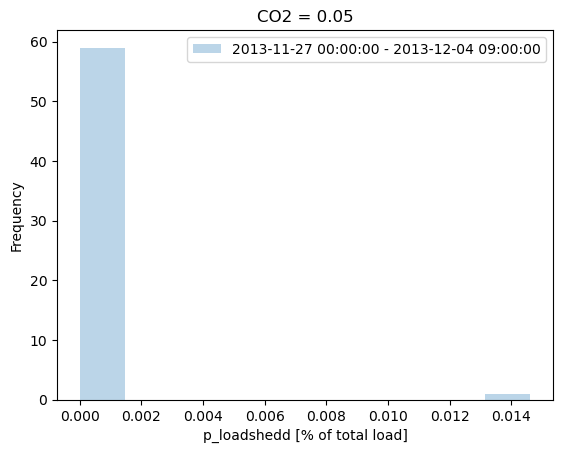

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


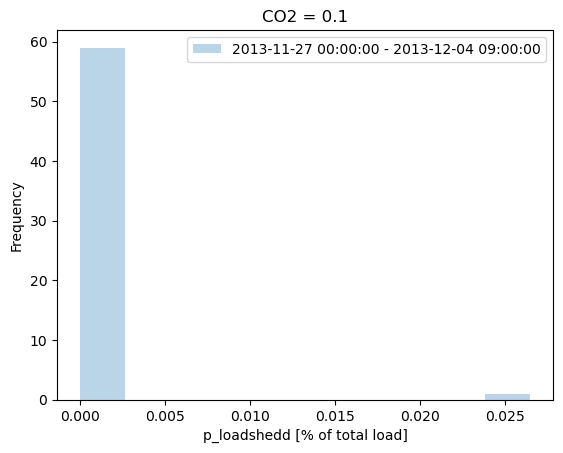

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


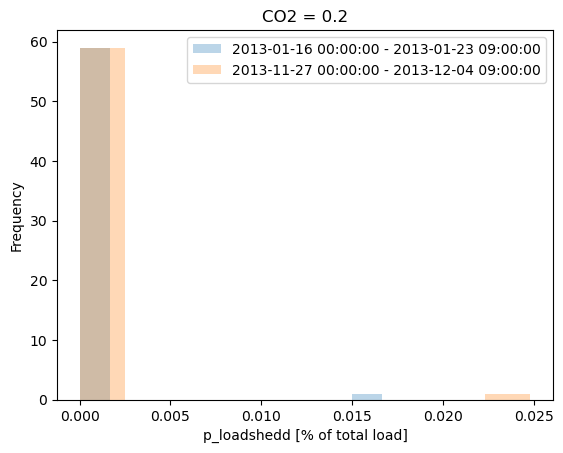

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


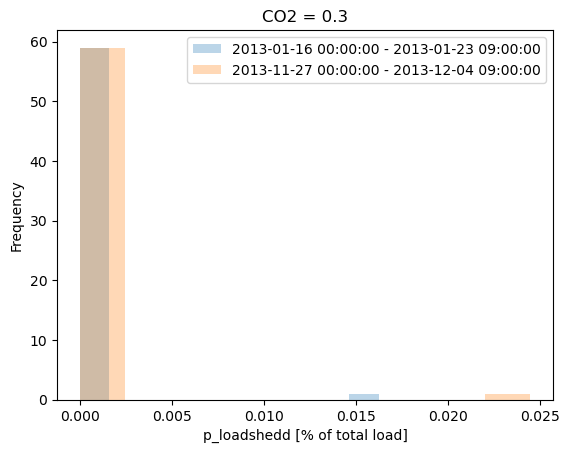

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


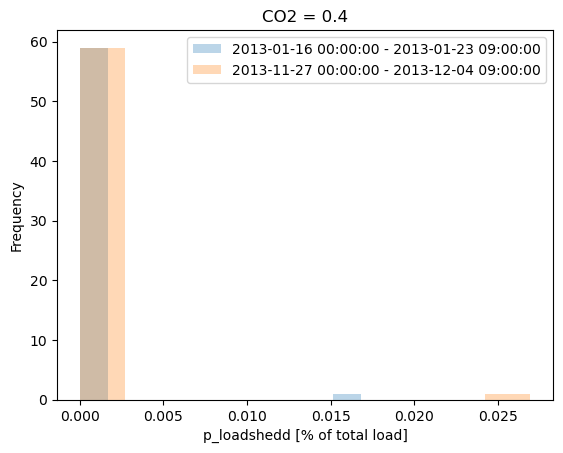

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


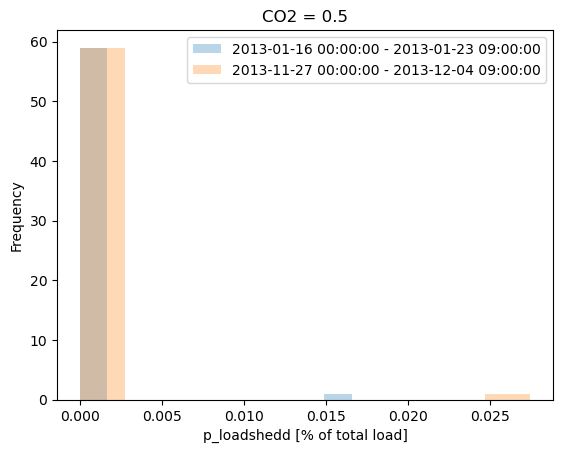

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-44.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


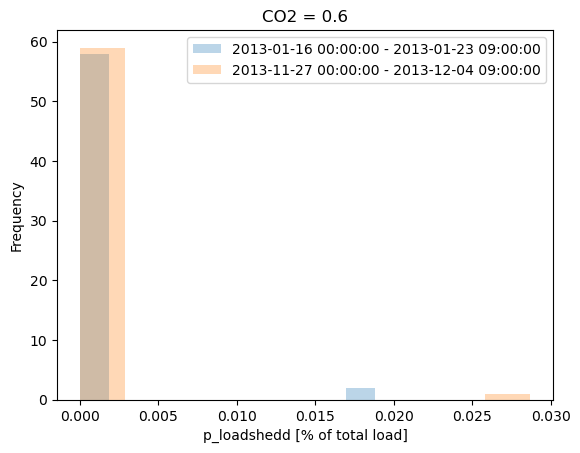

In [43]:


for lx,level in enumerate(co2ls):
    # lx = 0
    # level = co2ls[lx]
    
    fig,ax = plt.subplots(1,1)
#     k = loadshedd_data[lx,2][0]
#     network = data_handling.load_pypsa_network(f"../workflow/postnetworks/Co2L{level}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc",use_sclopf=True) #data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2ls[0]}.nc",use_sclopf=True)
#     loadshedd_power = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
#                         network.generators["carrier"]).sum().loc['load']
#     total_power = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
#                 network.generators["carrier"]).sum().sum(axis = 0)


    for k in loadshedd_data[lx,2]:
        network = data_handling.load_pypsa_network(f"../workflow/postnetworks/Co2L{level}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc",use_sclopf=True) #data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2ls[0]}.nc",use_sclopf=True)

        loadshedd_power = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
                network.generators["carrier"]).sum().loc['load']

        total_power = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
                network.generators["carrier"]).sum().sum(axis = 0)
        (loadshedd_power/total_power*100).plot.hist(alpha = 0.3,label = f"{min(network.snapshots)} - {max(network.snapshots)}")

    plt.legend()

    plt.xlabel(f'p_loadshedd [% of total load]')
    plt.title(fr"CO2 = {level}")

    plt.show()

Text(0.5, 0, 'p [% of total load]')

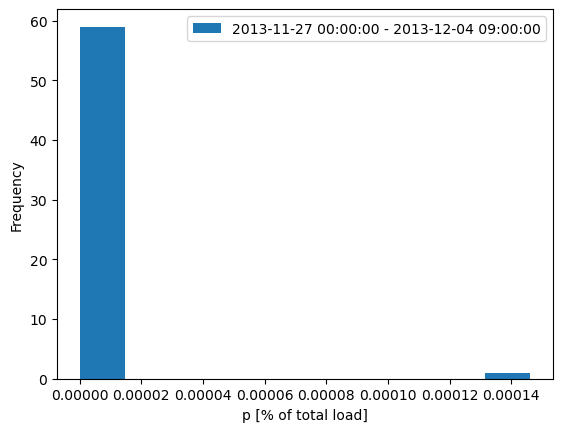

In [24]:
(loadshedd_power/total_power)


snapshot
2013-11-27 00:00:00    0.000000
2013-11-27 03:00:00    0.000000
2013-11-27 06:00:00    0.000000
2013-11-27 09:00:00    0.000000
2013-11-27 12:00:00    0.000000
2013-11-27 15:00:00    0.000000
2013-11-27 18:00:00    0.000000
2013-11-27 21:00:00    0.000000
2013-11-28 00:00:00    0.000000
2013-11-28 03:00:00    0.000000
2013-11-28 06:00:00    0.000000
2013-11-28 09:00:00    0.000000
2013-11-28 12:00:00    0.000000
2013-11-28 15:00:00    0.000146
2013-11-28 18:00:00    0.000000
2013-11-28 21:00:00    0.000000
2013-11-29 00:00:00    0.000000
2013-11-29 03:00:00    0.000000
2013-11-29 06:00:00    0.000000
2013-11-29 09:00:00    0.000000
2013-11-29 12:00:00    0.000000
2013-11-29 15:00:00    0.000000
2013-11-29 18:00:00    0.000000
2013-11-29 21:00:00    0.000000
2013-11-30 00:00:00    0.000000
2013-11-30 03:00:00    0.000000
2013-11-30 06:00:00    0.000000
2013-11-30 09:00:00    0.000000
2013-11-30 12:00:00    0.000000
2013-11-30 15:00:00    0.000000
2013-11-30 18:00:00    0.000000

In [110]:
network = data_handling.load_pypsa_network(f"../workflow/postnetworks/Co2L{level}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc",use_sclopf=True) #data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2ls[0]}.nc",use_sclopf=True)

generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)

emission_by_co2l = pd.Series(index = co2ls,)
lopf_CO2_global = pd.Series(index = co2ls)

percentage_loadshedd_data = np.zeros(len(co2ls))

objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc",use_sclopf=True) # data_handling.load_pypsa_network(f"../workflow/postnetworks/Co2L{level}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc",use_sclopf=True) #

    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
    
    percentage_loadshedd_data[i] = loadshedd_data[i,0]/ network.loads_t.p.sum().sum()
    lopf_CO2_global[level] = network.global_constraints["constant"]["CO2Limit"]

    emission_by_co2l[level] = checks.get_emissions(network)#
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-48.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.3.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.4.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:

In [112]:
loadshedd_data

array([[160.3989947373332,
        list([[Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [298.81057691788385,
        list([[Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [475.01149591199214,
        list([[Timestamp('2013-01-16 00:00:00'), Timestamp('2013-01-23 09:00:00')], [Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [469.5107685533728,
        list([[Timestamp('2013-01-16 00:00:00'), Timestamp('2013-01-23 09:00:00')], [Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [493.10464380416806,
        list([[Timestamp('2013-01-16 00:00:00'), Timestamp('2013-01-23 09:00:00')], [Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [498.7655426437384,
        list([[Timestamp('2013-01-16 00:00:00'), Timestamp('2013-01-23 09:00:00')], [Timestamp('2013-11-27 00:00:00'), Timestamp('2013-12-04 09:00:00')]])],
       [745.0105746944794,
      

In [85]:
network = pypsa.Network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{co2ls[0]}.nc")

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


In [86]:
duplicated_lines = network.lines[network.lines.index.str[-6:] != "outage"].index
network.lines.loc[duplicated_lines + "_outage", "num_parallel"]

Line
1_outage      1.000000
10_outage     1.000000
100_outage    1.000000
101_outage    0.289474
102_outage    1.000000
                ...   
94_outage     1.000000
95_outage     0.289474
96_outage     1.000000
97_outage     0.289474
98_outage     1.000000
Name: num_parallel, Length: 166, dtype: float64

In [113]:
generation_by_carrier_and_co2l

,0.05,0.1,0.2,0.3,0.4,0.5,0.6
Carrier,,,,,,,
nuclear,5.382507e+08,5.921373e+08,6.217495e+08,6.327714e+08,6.465448e+08,6.514138e+08,6.572577e+08
oil,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
biomass,3.111539e+07,3.688161e+07,3.986658e+07,4.160080e+07,4.241829e+07,3.968186e+07,4.356199e+07
CCGT,1.675534e+08,3.384941e+08,3.401234e+08,2.398011e+08,1.716481e+08,1.349929e+08,1.452998e+08
lignite,1.276737e+07,2.462799e+07,1.439078e+08,2.791521e+08,3.373293e+08,3.968180e+08,4.403951e+08
coal,8.109668e+05,7.334974e+05,1.484044e+06,1.730939e+07,1.100222e+08,1.949201e+08,2.837462e+08
OCGT,0.000000e+00,4.677300e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
geothermal,3.825345e+05,4.171817e+05,4.402546e+05,4.486193e+05,4.646453e+05,4.748303e+05,5.136540e+05
offwind-dc,2.157762e+08,1.218659e+08,6.968910e+07,6.361564e+07,6.343056e+07,6.316820e+07,6.368446e+07


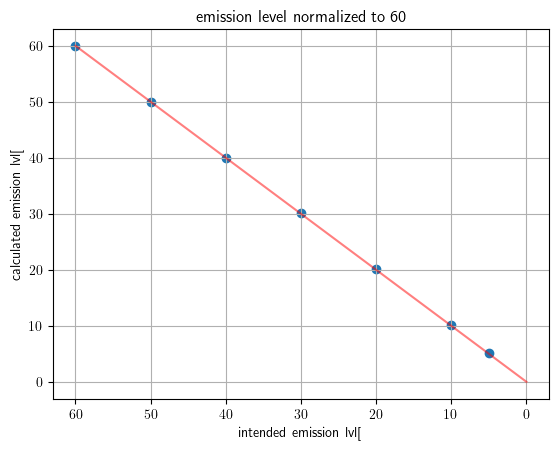

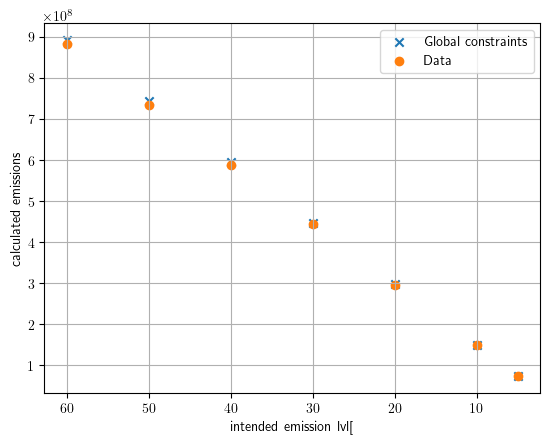

In [87]:
generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100
# generation_fossil, fossil_percentage

emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
# emission_by_co2l = emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l["0.6"]*60

# plot red line
plt.plot([60,0],[60,0], color = "r", alpha = 0.5)
plt.scatter(emission_by_co2l_perc.index.astype(float)*100, emission_by_co2l_perc.values)
plt.gca().invert_xaxis()
plt.grid()
plt.title("emission level normalized to 60%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")
plt.savefig(f"{imagepath}/co2plot_1")

plt.figure()
plt.scatter(lopf_CO2_global.index.astype(float)*100, lopf_CO2_global.values,label = "Global constraints",marker = "x")
plt.scatter(emission_by_co2l.index.astype(float)*100, emission_by_co2l.values,label = "Data")
plt.legend()
# plt.scatter(emission_by_co2l.index*100, emission_by_co2l.values)
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")
plt.savefig(f"{imagepath}/co2plot_2")

# 3. Generation Plot from paper 

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.6.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
/srv/data/jlange/PYPSA/conda_env/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/data/jlange/PYPSA/conda_env/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
/srv/data/jlange/PYPSA/conda_env/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn(

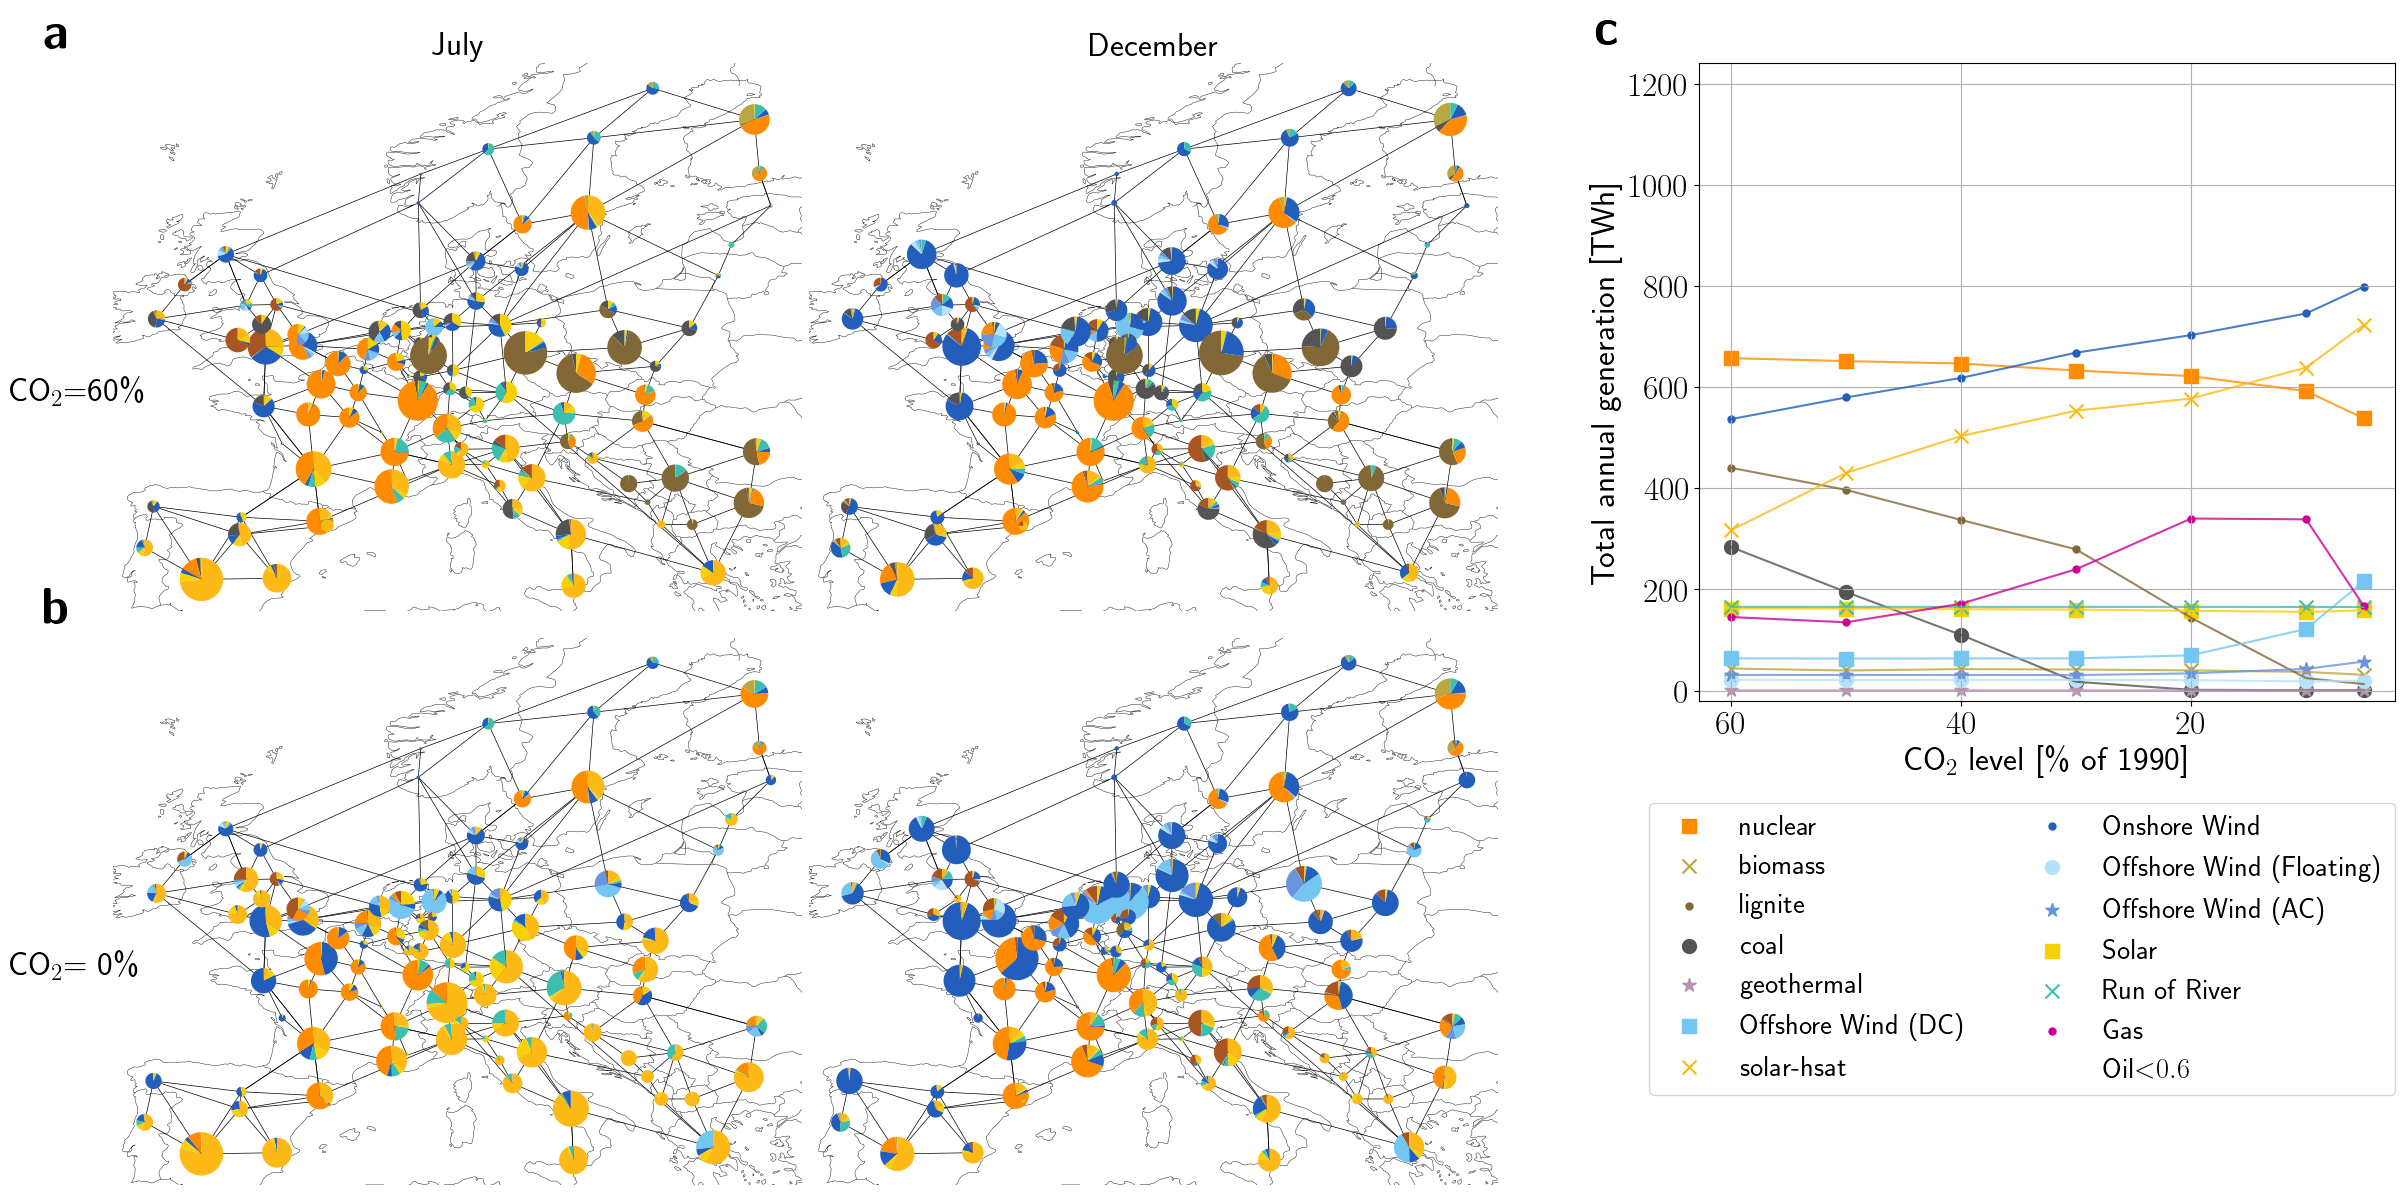

In [88]:
# path_to_pypsa_network_sclopf = "../../PYPSA2/sclopf-iter/workflow/postnetworks"

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [max(co2ls), min(co2ls)]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_primary = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

n_nodes = n_nodes
vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
       # fpath = data_path + "European_networks_lopf/elec_s_800_ec_lv1.0_Co2L0.1-3H.nc"
       # n = data_handling.load_pypsa_network(fpath, False)
       
       n = data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}.nc",use_sclopf=True)
       
       # n = data_handling.load_pypsa_network(target_level, n_nodes, path_to_pypsa_network_sclopf)
       for j, month in enumerate(months):

              axs_primary[i][j].set_ylim([0, vmax])
              current_snapshots = n.snapshots[n.snapshots.month == month]
              current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
              current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
              n.plot(bus_sizes=current_gen/7e6,
                     line_colors='black',
                     link_colors='black',
                     link_widths=0.5,
                     line_widths=0.5,
                     ax=axs_primary[i][j])

              if i == 0:
                     axs_primary[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

              axs_primary[i][j].text(0 - 0.1, 1+0.05,
                            labels[i][j],
                            fontsize=36,
                            weight='bold',
                            verticalalignment='center',
                            transform=axs_primary[i][j].transAxes)


axs_primary[0][0].text(0 - 0.15, 0.4,
               r'CO$_2$=60\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[0][0].transAxes)
axs_primary[1][0].text(0 - 0.15, 0.4,
               r'CO$_2$= 0\%',
               fontsize=24,
               verticalalignment='center',
               transform=axs_primary[1][0].transAxes)

###### panel c ######

##### old
# co2s = generation_by_carrier_and_co2l.columns.astype('float')
# index = np.argsort(co2s)
# generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
# for ind,data in generation_by_carrier_and_co2l.iterrows():
#     ax3.scatter(co2s[index]*100,
#                 (data.values)[index]*1e-6,
#                 color=n.carriers.set_index('nice_name').color.loc[ind],
#                 label=ind,
#                 s=100)

#     ax3.plot(co2s[index]*100,
#              (data.values)[index]*1e-6,
#              color=n.carriers.set_index('nice_name').color.loc[ind])
    
    
import itertools
marker = itertools.cycle((',', 'x', '.', 'o', '*')) 

colors_gens = network.carriers.set_index('nice_name').color
colors_gens["Open-Cycle Gas"] = "#cc0099"
colors_gens["Gas"] = "#cc0099"

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
jitter = iter(np.linspace(-1,1,generation_by_carrier_and_co2l.shape[0]))

generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
gas_gen = generation_by_carrier_and_co2l.loc["Combined-Cycle Gas"] + generation_by_carrier_and_co2l.loc["Open-Cycle Gas"]
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l.copy()

generation_by_carrier_and_co2l_plot.drop("oil", axis=0, inplace=True)

for col in generation_by_carrier_and_co2l_plot.index:
    if "Gas" in col:
        generation_by_carrier_and_co2l_plot.drop(col, axis=0, inplace=True)
generation_by_carrier_and_co2l_plot = generation_by_carrier_and_co2l_plot.rename(index=network.carriers.nice_name)
generation_by_carrier_and_co2l_plot.loc["Gas"] = gas_gen 
for ind,data in generation_by_carrier_and_co2l_plot.iterrows():
    # jit = next(jitter)
    jit = 0
    plot_inds = (data.values)[index]>0
    # print(plot_inds.sum())
    ax3.scatter((co2s[index]*100 + jit)[plot_inds],
                ((data.values)[index]*1e-6)[plot_inds],
                color=colors_gens.loc[ind],
                label=ind,
                s=100,
                marker= next(marker)
                )

    ax3.plot((co2s[index]*100 + jit)[plot_inds],
             ((data.values)[index]*1e-6)[plot_inds],
             color=colors_gens.loc[ind],
             alpha=0.8)
# plt.gca().set_yscale("log")
ax3.scatter([], [], label=r"Oil$\textless 0.6$", marker="")


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
# ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
# ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12.4e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(f"{imagepath}"+'/' + 'generation_mix_versus_co2level.pdf', bbox_inches='tight')

In [89]:
network.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
AC,0.0000,#70af1d,AC,inf,0.0
DC,0.0000,#8a1caf,DC,inf,0.0
nuclear,0.0000,#ff8c00,nuclear,inf,0.0
oil,0.2571,#c9c9c9,oil,inf,0.0
biomass,0.0000,#baa741,biomass,inf,0.0
CCGT,0.1980,#a85522,Combined-Cycle Gas,inf,0.0
lignite,0.4069,#826837,lignite,inf,0.0
coal,0.3361,#545454,coal,inf,0.0
OCGT,0.1980,#e0986c,Open-Cycle Gas,inf,0.0


In [73]:
data

0.05    0.0
0.1     0.0
0.2     0.0
0.3     0.0
0.4     0.0
0.5     0.0
0.6     0.0
Name: load, dtype: float64

# 4. Storage Output Capacity

NameError: name 'network' is not defined

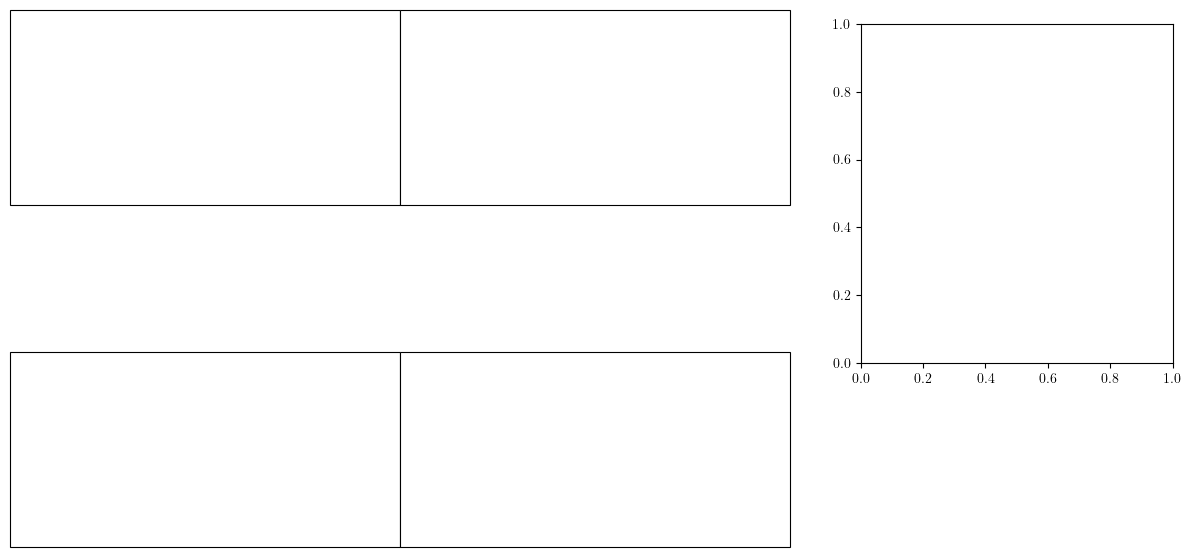

In [ ]:
# select whether to plot the storage OUTPUT capacity (capacity * output efficiency) or the storage capacity
for plot_output_capacity in [False, True]:

       mpl.style.use('default')
       plt.rc('text', usetex=True)
       plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

       target_levels = [max(co2ls), min(co2ls)]
       unit = "GWh"
       unit_factor = 1e-3

       f = plt.figure(figsize=(15,10))

       gs = GridSpec(1, 2, width_ratios=[2,0.8], wspace=0.13)
       gs_maps = GridSpecFromSubplotSpec(2, 2, subplot_spec = gs[0], wspace=-0.0, hspace=-0.2)
       gs_lines = GridSpecFromSubplotSpec(3, 1, subplot_spec = gs[1], height_ratios=[0.1,0.4,0.3])

       axs_maps = np.array([[f.add_subplot(gs_maps[j, i], projection=ccrs.PlateCarree())
              for i in range(2)] for j in range(2)])
       ax_line = f.add_subplot(gs_lines[1])

       ##### panal a, b: maps #######

       buses = list(network.buses.index)
       storage_types = network.storage_units["carrier"].unique()
       multi_index = pd.MultiIndex.from_product([buses, storage_types], names=["bus", "carrier"])

       battery_color = "red"
       h2_color = "green"
       for i, target_level in enumerate(target_levels):
              for j, (current_store_type, current_color) in enumerate(zip(["battery", "H2"], [battery_color, h2_color])):
                     n = data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}.nc",use_sclopf=True)
                     storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom
                     if plot_output_capacity:
                            storage_capacities = n.storage_units.max_hours * n.storage_units.p_nom * n.storage_units.efficiency_dispatch
                     storage_capacities_grouped = storage_capacities.groupby([n.storage_units["bus"], n.storage_units["carrier"]]).sum()
                     max_node_size = 0.85
                     max_capacity = storage_capacities_grouped[:,current_store_type].max()
                     max_capacity_rounded = round(max_capacity, -int(round(np.log10(max_capacity),0))+1)
                     n.plot(bus_sizes=storage_capacities_grouped[:,current_store_type]/max_capacity_rounded*max_node_size,
                            line_colors='black',
                            bus_colors=current_color,
                            link_widths=0.5,
                            line_widths=0.5,
                            ax=axs_maps[i,j])
                     legend_relative_circle_size = np.array([0.25, 1])
                     legend_circle_size = [size*max_node_size for size in legend_relative_circle_size]
                     axs_maps[i,j].legend(loc="upper left")
                     pypsa.plot.add_legend_circles(axs_maps[i,j], sizes=legend_circle_size, labels=[f"{size*max_capacity_rounded*unit_factor:2g} {unit}" for size in legend_circle_size], patch_kw={"color":current_color})
                     

                     # set current_store_type to upper case
                     current_store_type_string = current_store_type[0].upper() + current_store_type[1:]
                     axs_maps[0,j].set_title(current_store_type_string, fontsize=16)
                     
       axs_maps[0,0].text(0 - 0.1, 1,
                     r'\textbf{a}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.1, 1,
                     r'\textbf{b}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       axs_maps[0,0].text(0 - 0.15, 0.4,
                     r'CO$_2$=60\% ',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[0,0].transAxes)
       axs_maps[1,0].text(0 - 0.15, 0.4,
                     r'CO$_2$= 0\%',
                     fontsize=16,
                     verticalalignment='center',
                     transform=axs_maps[1,0].transAxes)


       ###### panel c: total capacity line plot #####

       ax_line.text(0 - 0.1, 1+0.05,
                     r'\textbf{c}',
                     fontsize=24,
                     weight='bold',
                     verticalalignment='center',
                     transform=ax_line.transAxes)

       capacity_by_type_by_lvl = pd.DataFrame(index=storage_types, columns=co2ls[::-1])
       for target_level in co2ls:
              
              n = data_handling.load_pypsa_network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}.nc",use_sclopf=True)
              print(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{target_level}.nc")
              storage_capacities_all_lvl = pd.Series(index=multi_index, data=0)
              storage_capacities_lvl = n.storage_units.max_hours * n.storage_units.p_nom
              if plot_output_capacity:
                     storage_capacities_lvl = storage_capacities_lvl * n.storage_units.efficiency_dispatch
              storage_capacities_grouped_lvl = storage_capacities_lvl.groupby([n.storage_units["carrier"]]).sum()
              capacity_by_type_by_lvl.loc[storage_capacities_grouped_lvl.index,target_level] = storage_capacities_grouped_lvl

              capacity_by_type_by_lvl_plotting = capacity_by_type_by_lvl.T.copy()
       try:
              capacity_by_type_by_lvl_plotting.drop(index=[0.7,0.8], inplace=True)
       except:
              pass

       capacity_by_type_by_lvl_plotting.rename(columns={"battery": "Battery", "hydro": "Hydro", "PHS": "Pumped hydro"},inplace=True)
       colors = ["blue", "skyblue", h2_color, battery_color]
       ax_line.plot([co2s[i]*100 for i in range(7)][::-1] ,capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor, label=['Hydro', 'Pumped hydro', 'H2','Battery'])
       for feat_count in range(4):
              plt.scatter([co2s[i]*100 for i in range(7)][::-1] ,(capacity_by_type_by_lvl_plotting.loc[:,['Hydro', 'Pumped hydro', 'H2','Battery']].values*unit_factor)[:,feat_count], color=colors[feat_count])
       secax = ax_line.secondary_yaxis('right', functions=(lambda x: x*(1/6), lambda x: x*6))
       secax.set_ylabel('Battery power [GW]')#, weight='normal')
       # secax.tick_params(labelsize=16)
       # secax.tick_params(axis='y', which='both', labelsize=10, width=1)

       for i,j in enumerate(ax_line.lines):
              j.set_color(colors[i])

       ax_line.invert_xaxis()
       ax_line.grid(True)
       plt.yscale('log')
       if plot_output_capacity:
              plt.ylabel(f"Storage output capacity [{unit}]")
       else:
              plt.ylabel(f"Storage capacity [{unit}]")
       plt.xlabel(r"CO2 level [\% of 1990]")
       plt.legend()
       h, l = ax_line.get_legend_handles_labels()
       ax_line.get_legend().remove()
       ax_line_legend = f.add_subplot(gs_lines[2])
       ax_line_legend.legend(h, l, borderaxespad=0.2, fontsize=16, ncol=1, loc="upper left")
       ax_line_legend.axis("off")

       if plot_output_capacity:
              file_name = "storage_output_capacity_vs_co2level"
       else:
              file_name = "storage_capacityvs_co2level"

       plt.savefig(imagepath +'/' + file_name + f'_{n_nodes}' '.pdf', bbox_inches='tight')

# 5. Storage over the year

In [92]:
i = pypsa.Network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc") #sclopf network


group_size = 60
snapshots = i.snapshots#n.snapshots[group_size * k : group_size * k + group_size]

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported networ

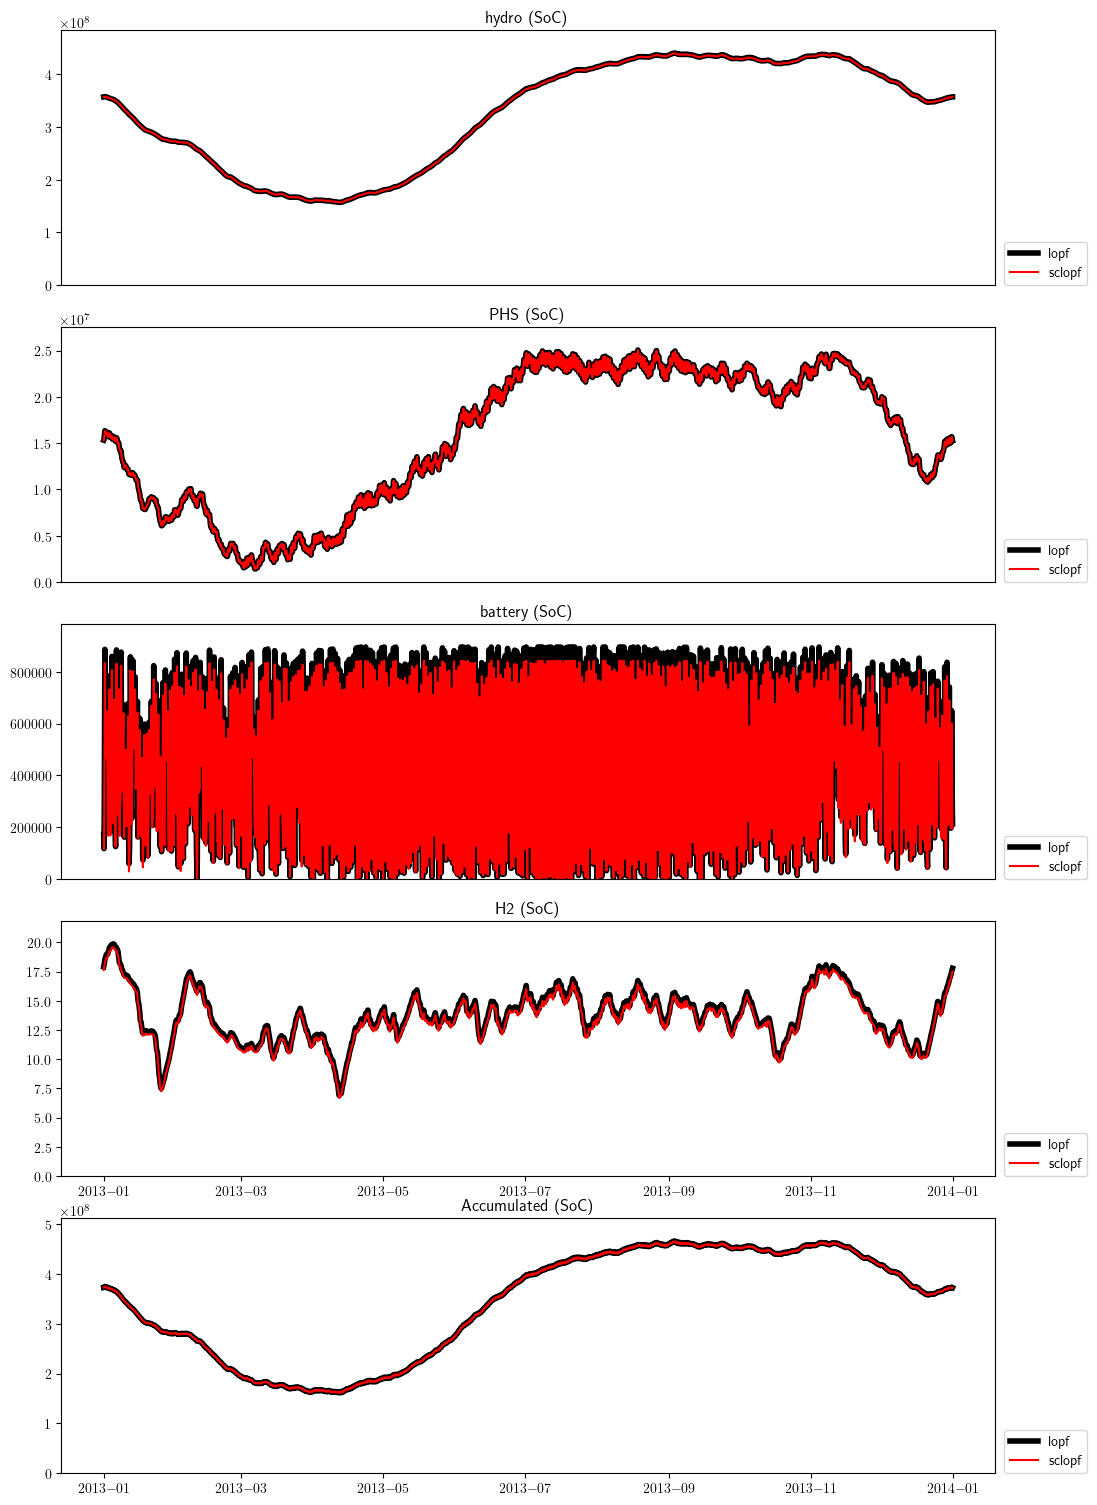

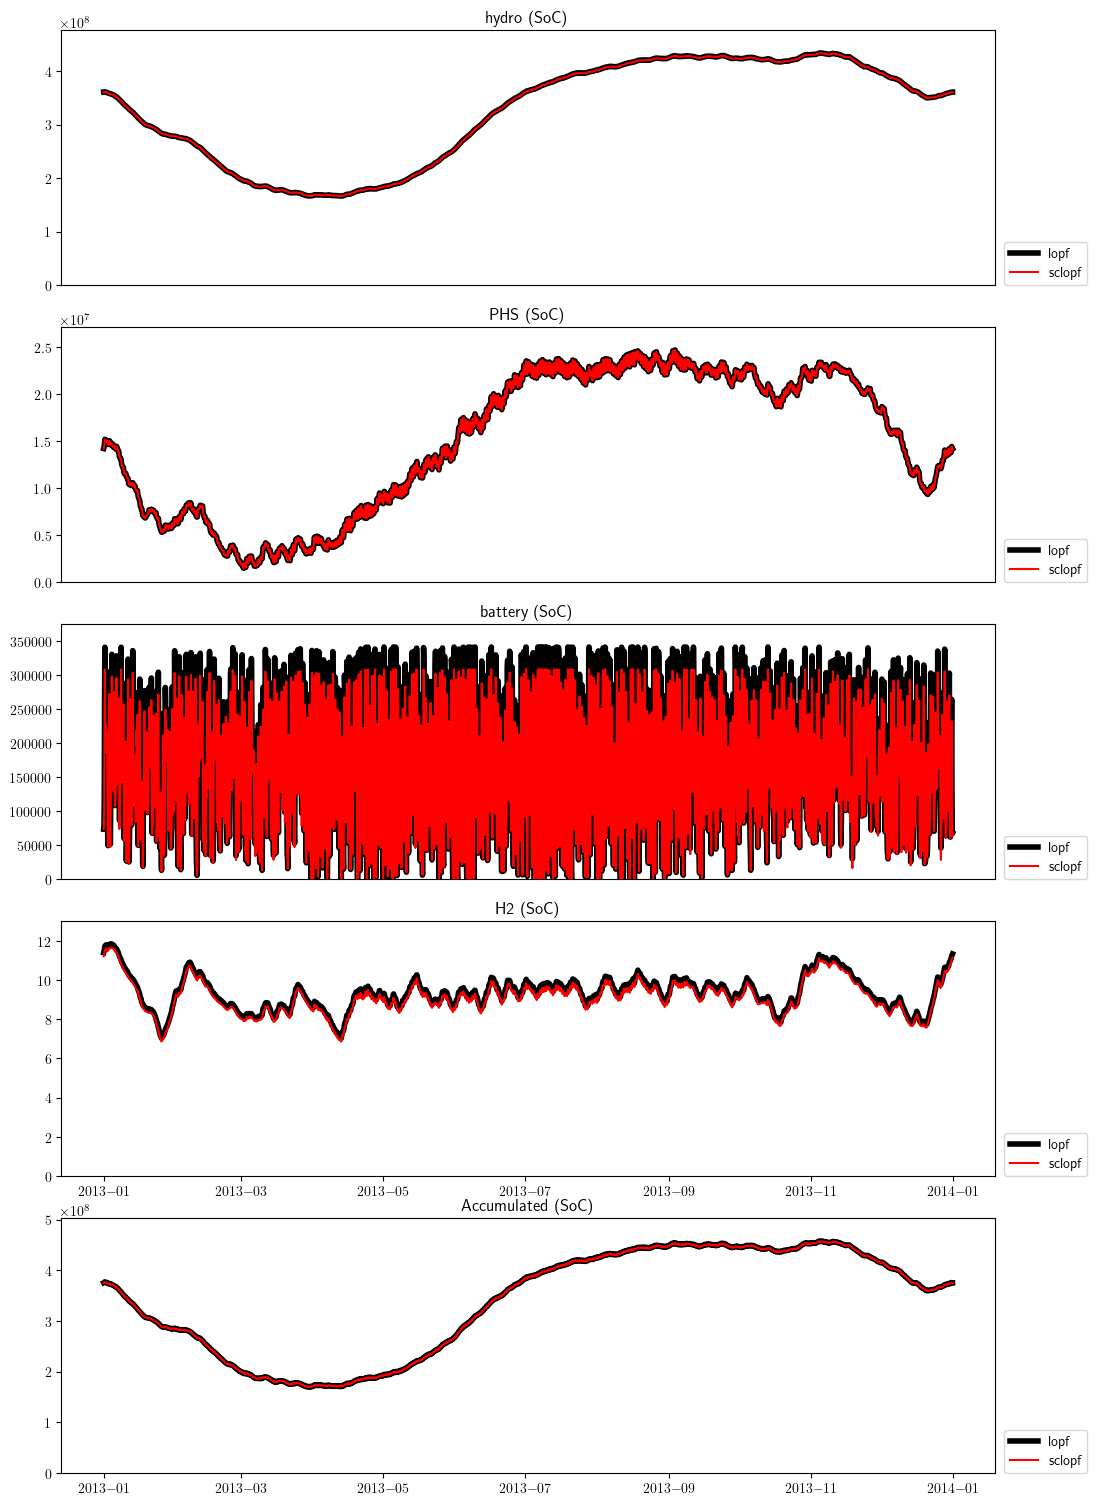

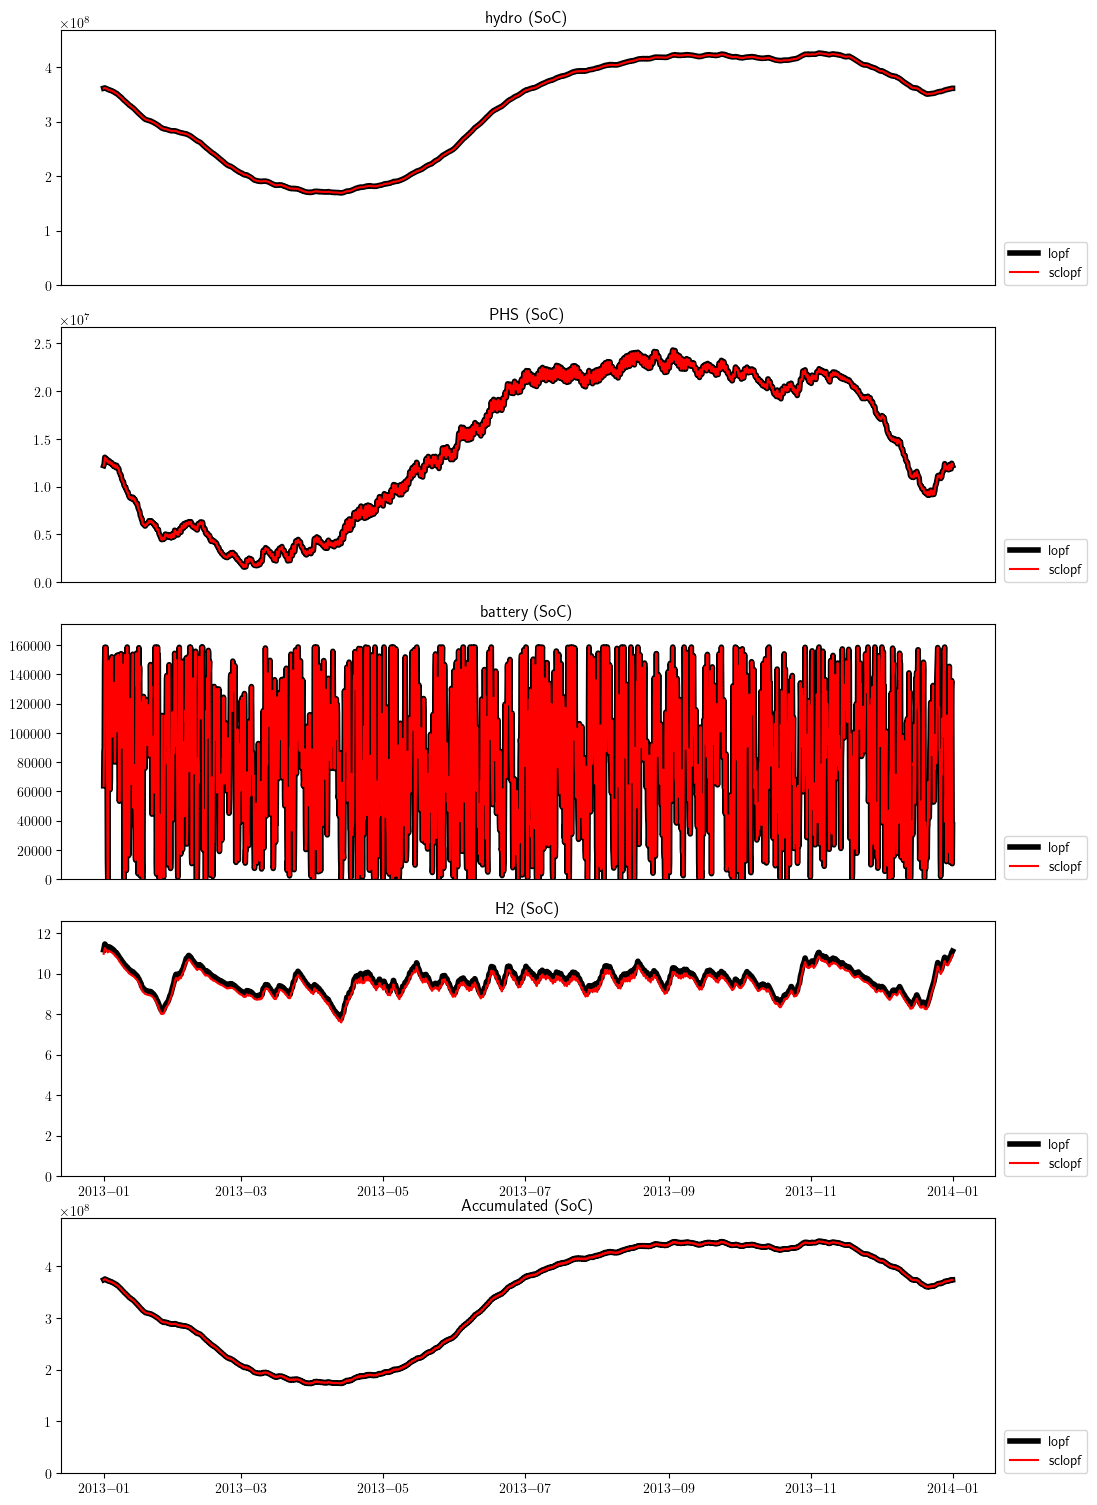

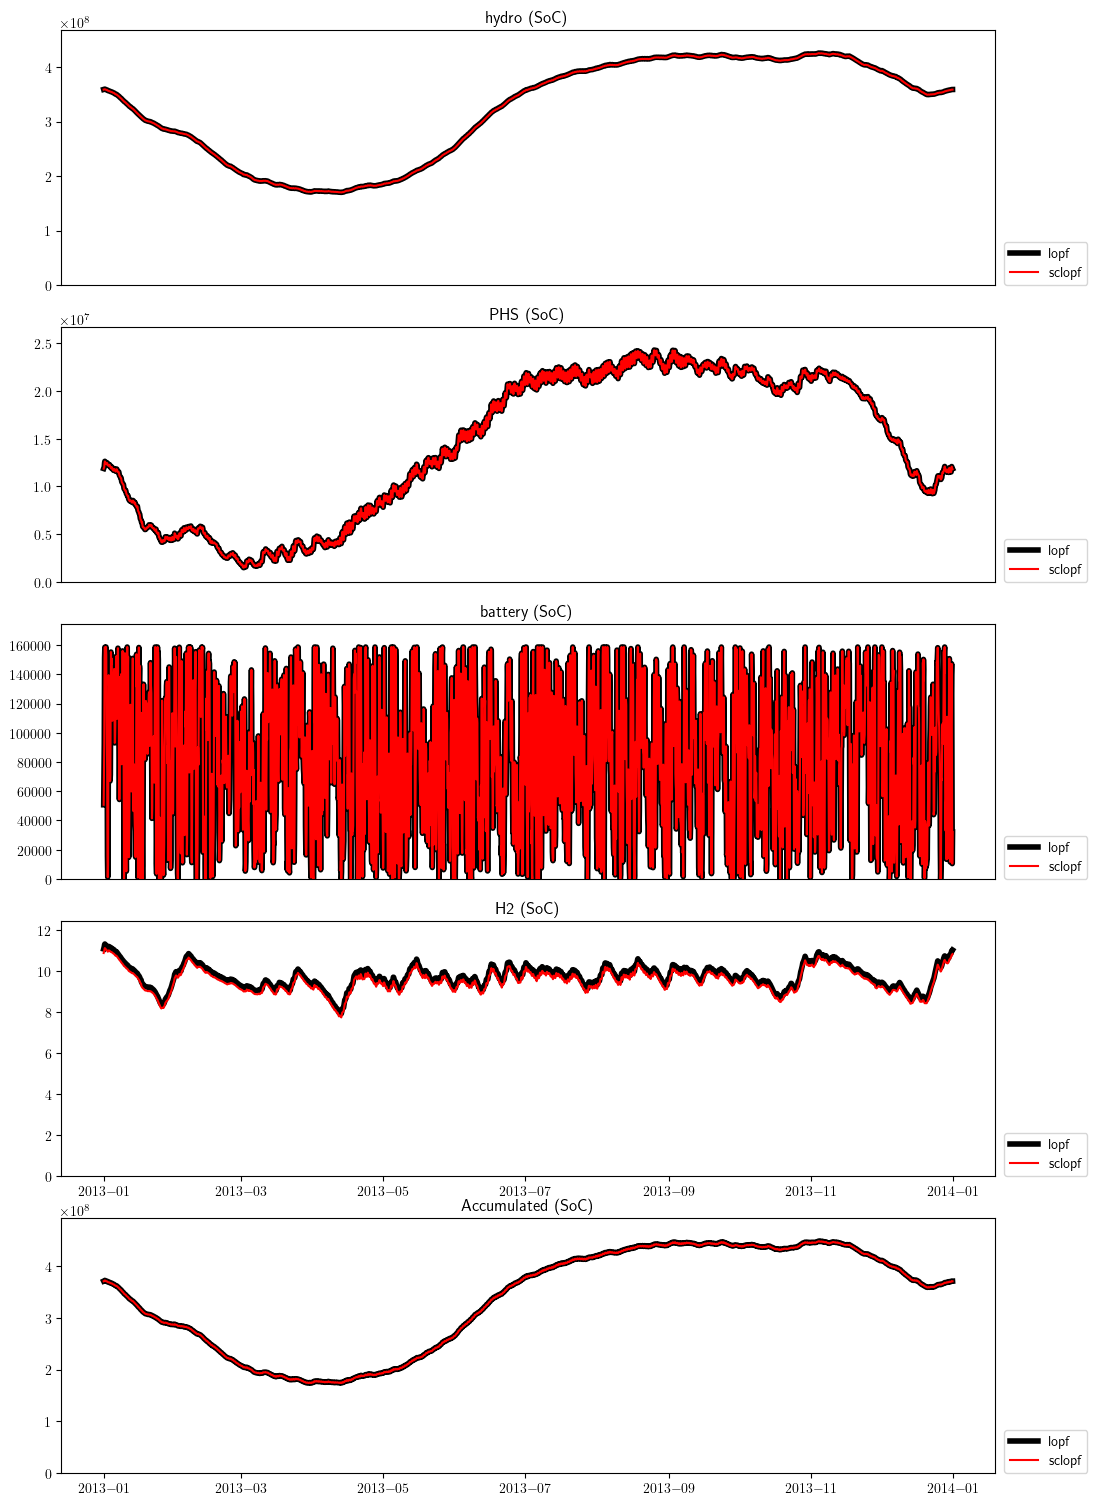

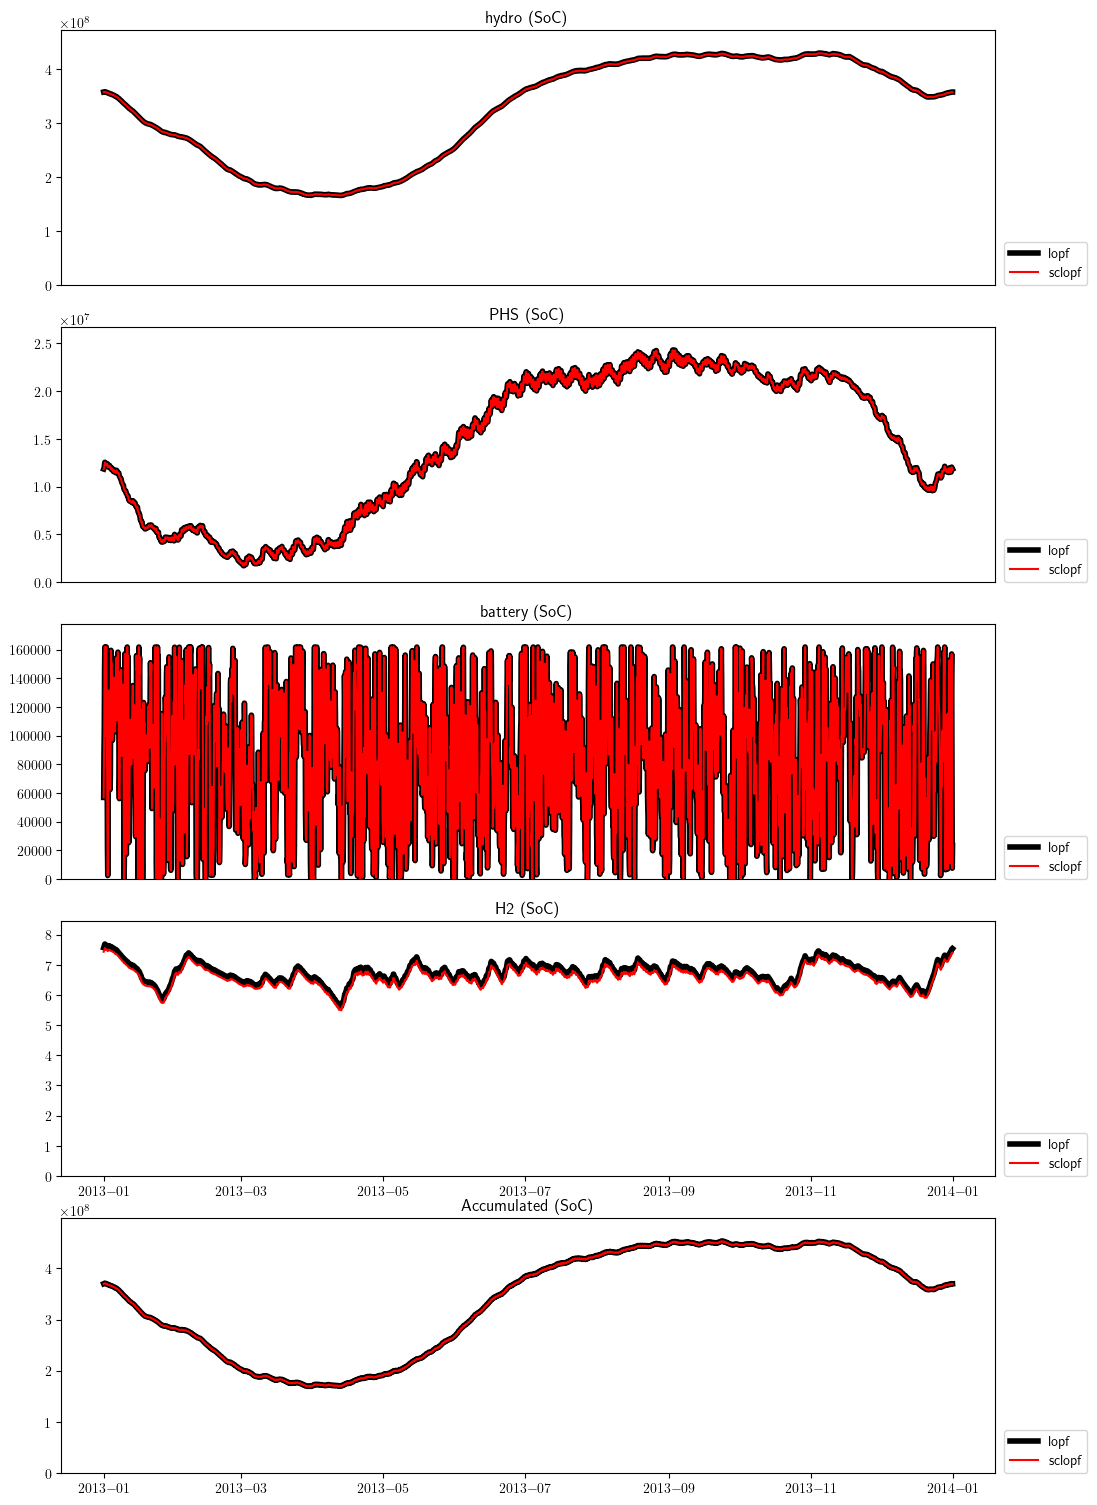

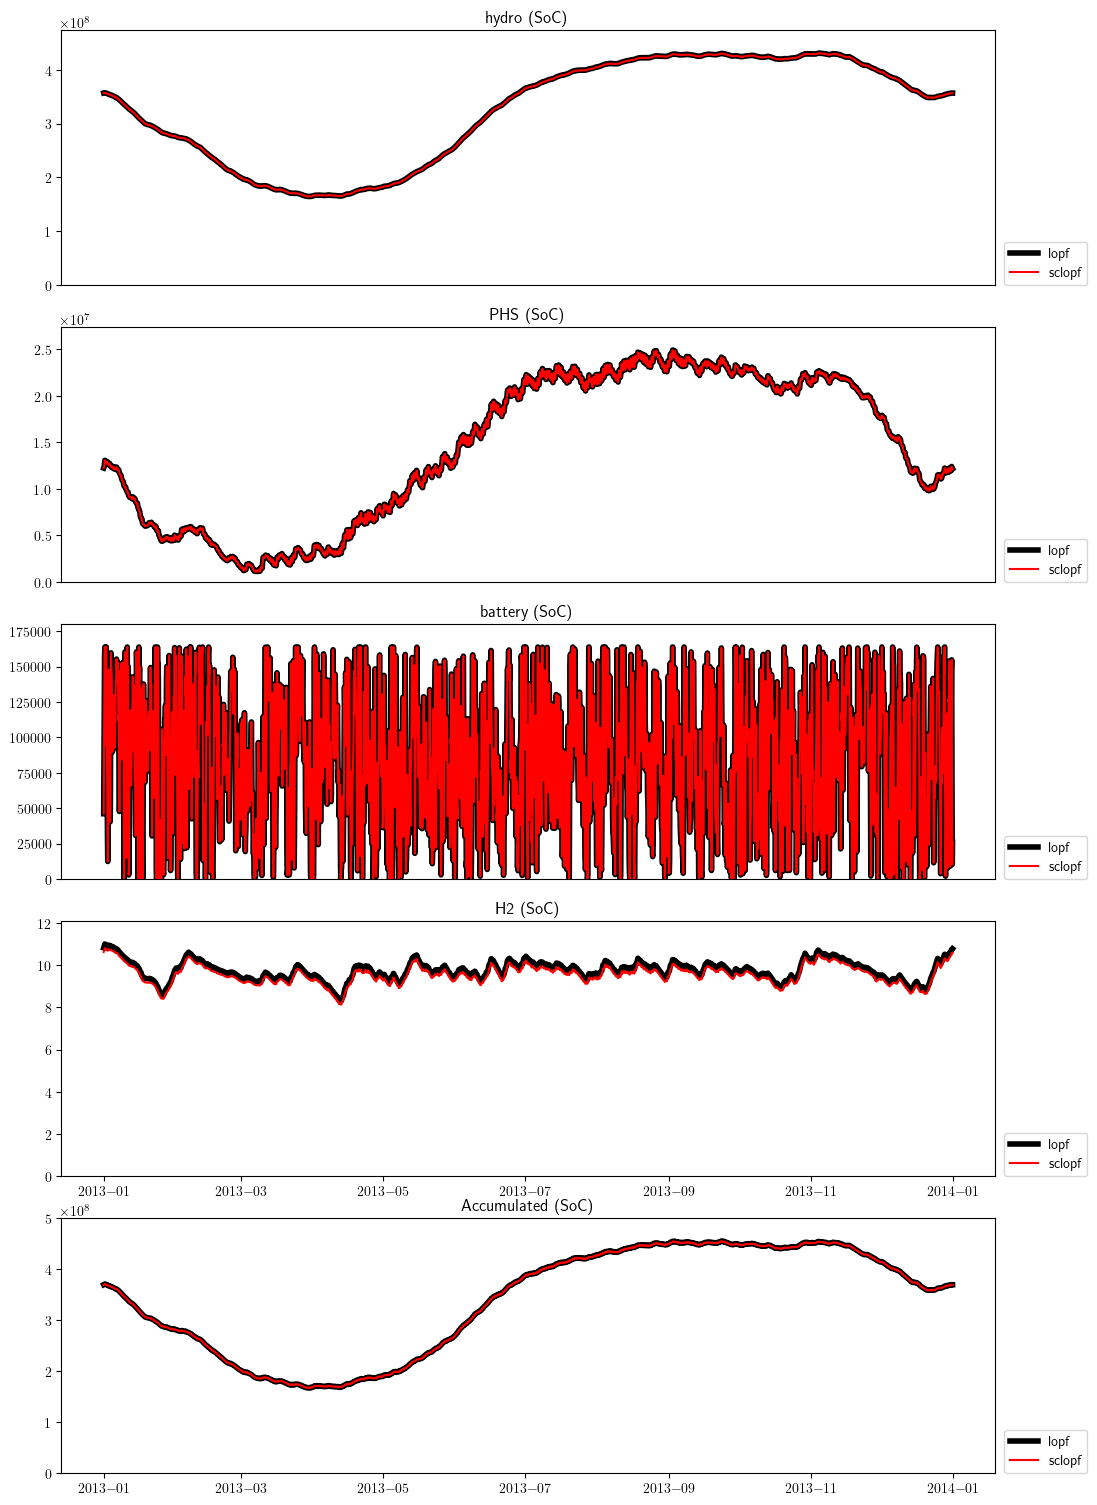

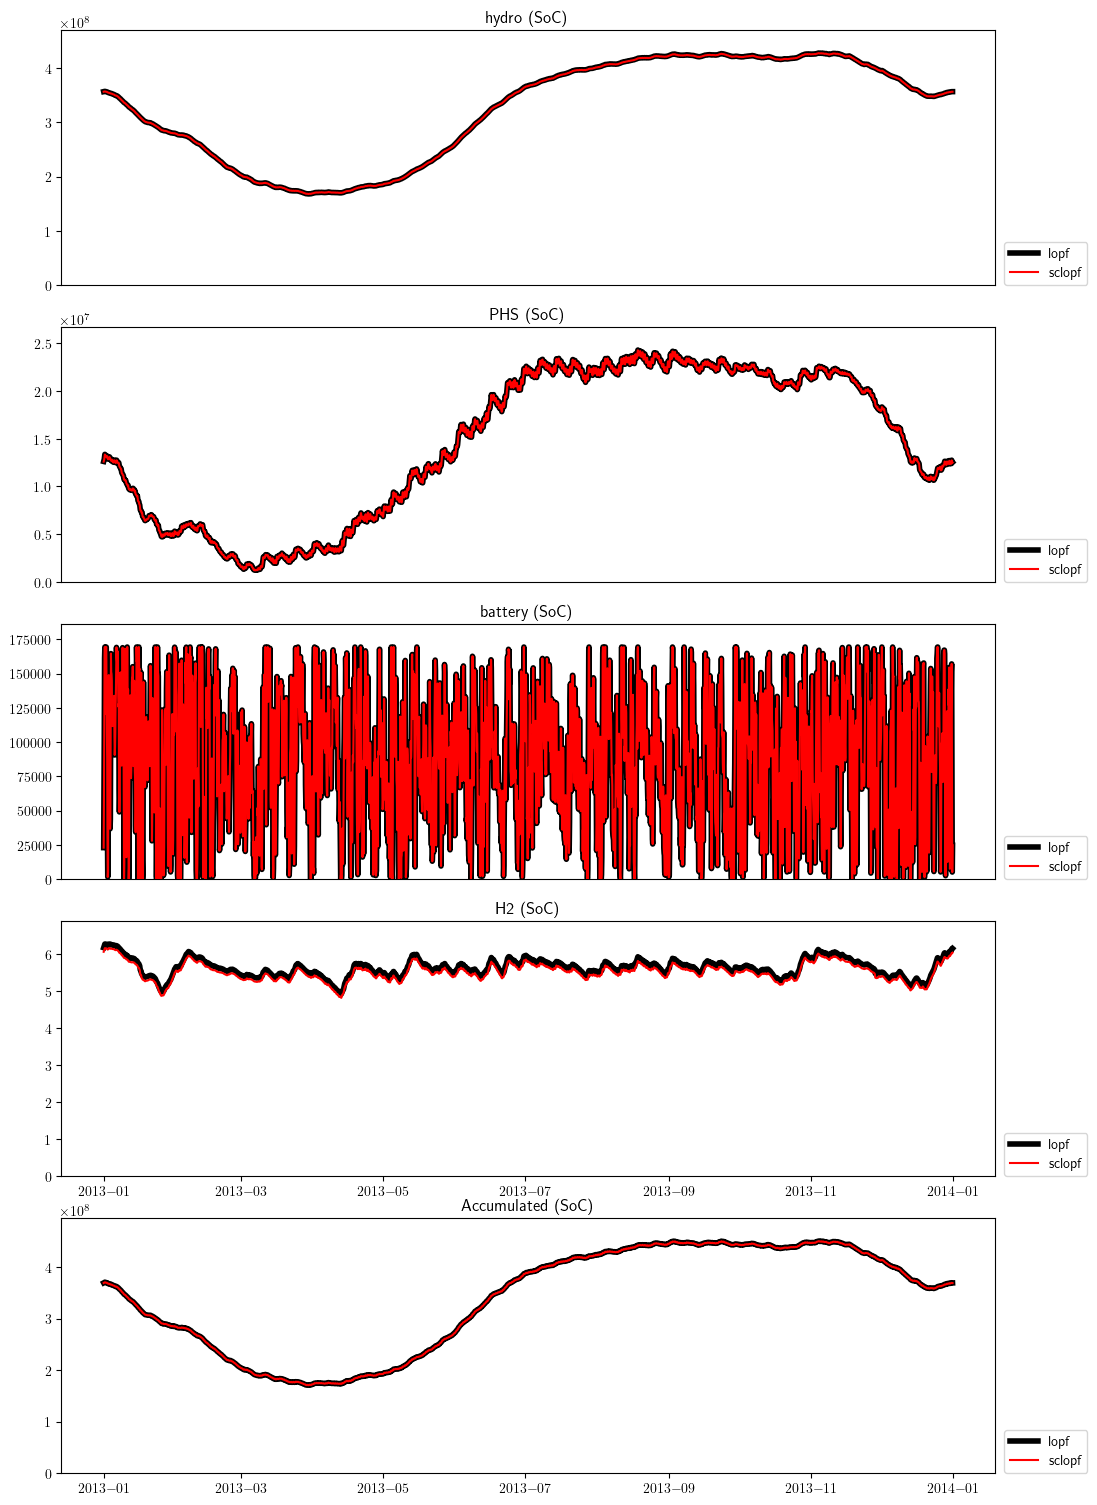

In [93]:
for level in co2ls:

    n = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc") #lopf
    i = pypsa.Network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc") #sclopf network


    fig, axes = plt.subplots(len(n.storage_units.carrier.unique())+1, 1, figsize=(10, 15))
    fig.tight_layout()

    c = 0
    techsu = n.storage_units.carrier.unique()
    for ax in axes[:-1]:
        tech = techsu[c]
        disp_n = n.storage_units_t.state_of_charge.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.storage_units.carrier).sum().T[tech].loc[snapshots]
        disp_i = i.storage_units_t.state_of_charge.multiply(i.snapshot_weightings.objective,axis=0).T.groupby(i.storage_units.carrier).sum().T[tech].loc[snapshots]

        ax.set_title(tech + " (SoC)")
        ax.plot(disp_n, color="black", linewidth=4, label="lopf")
        ax.plot(disp_i, color="red", zorder=3, label="sclopf")
        ax.set_ylim([min([0, min(disp_n), min(disp_i)]), max([max(disp_n*1.1), max(disp_i*1.1)])])
        ax.legend(loc=[1.01, 0])
        if tech != "H2": ax.set_xticks([], [])
        c = c+1
        
    ax = axes[-1]

    disp_n = n.storage_units_t.state_of_charge.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.storage_units.carrier).sum().sum().loc[snapshots]
    disp_i = i.storage_units_t.state_of_charge.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.storage_units.carrier).sum().sum().loc[snapshots]

    ax.set_title("Accumulated (SoC)")
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.set_ylim([min([0, min(disp_n), min(disp_i)]), max([max(disp_n*1.1), max(disp_i*1.1)])])
    ax.legend(loc=[1.01, 0])

    plt.savefig(imagepath + "/"+  str(level)+'/' + "SoC" + '.pdf', bbox_inches='tight')

# 6. Generation over year

INFO:pypsa.io:Imported network elec_s_200_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_200_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network elec_s_200_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_200_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network elec_s_200_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_200_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported networ

KeyboardInterrupt: 

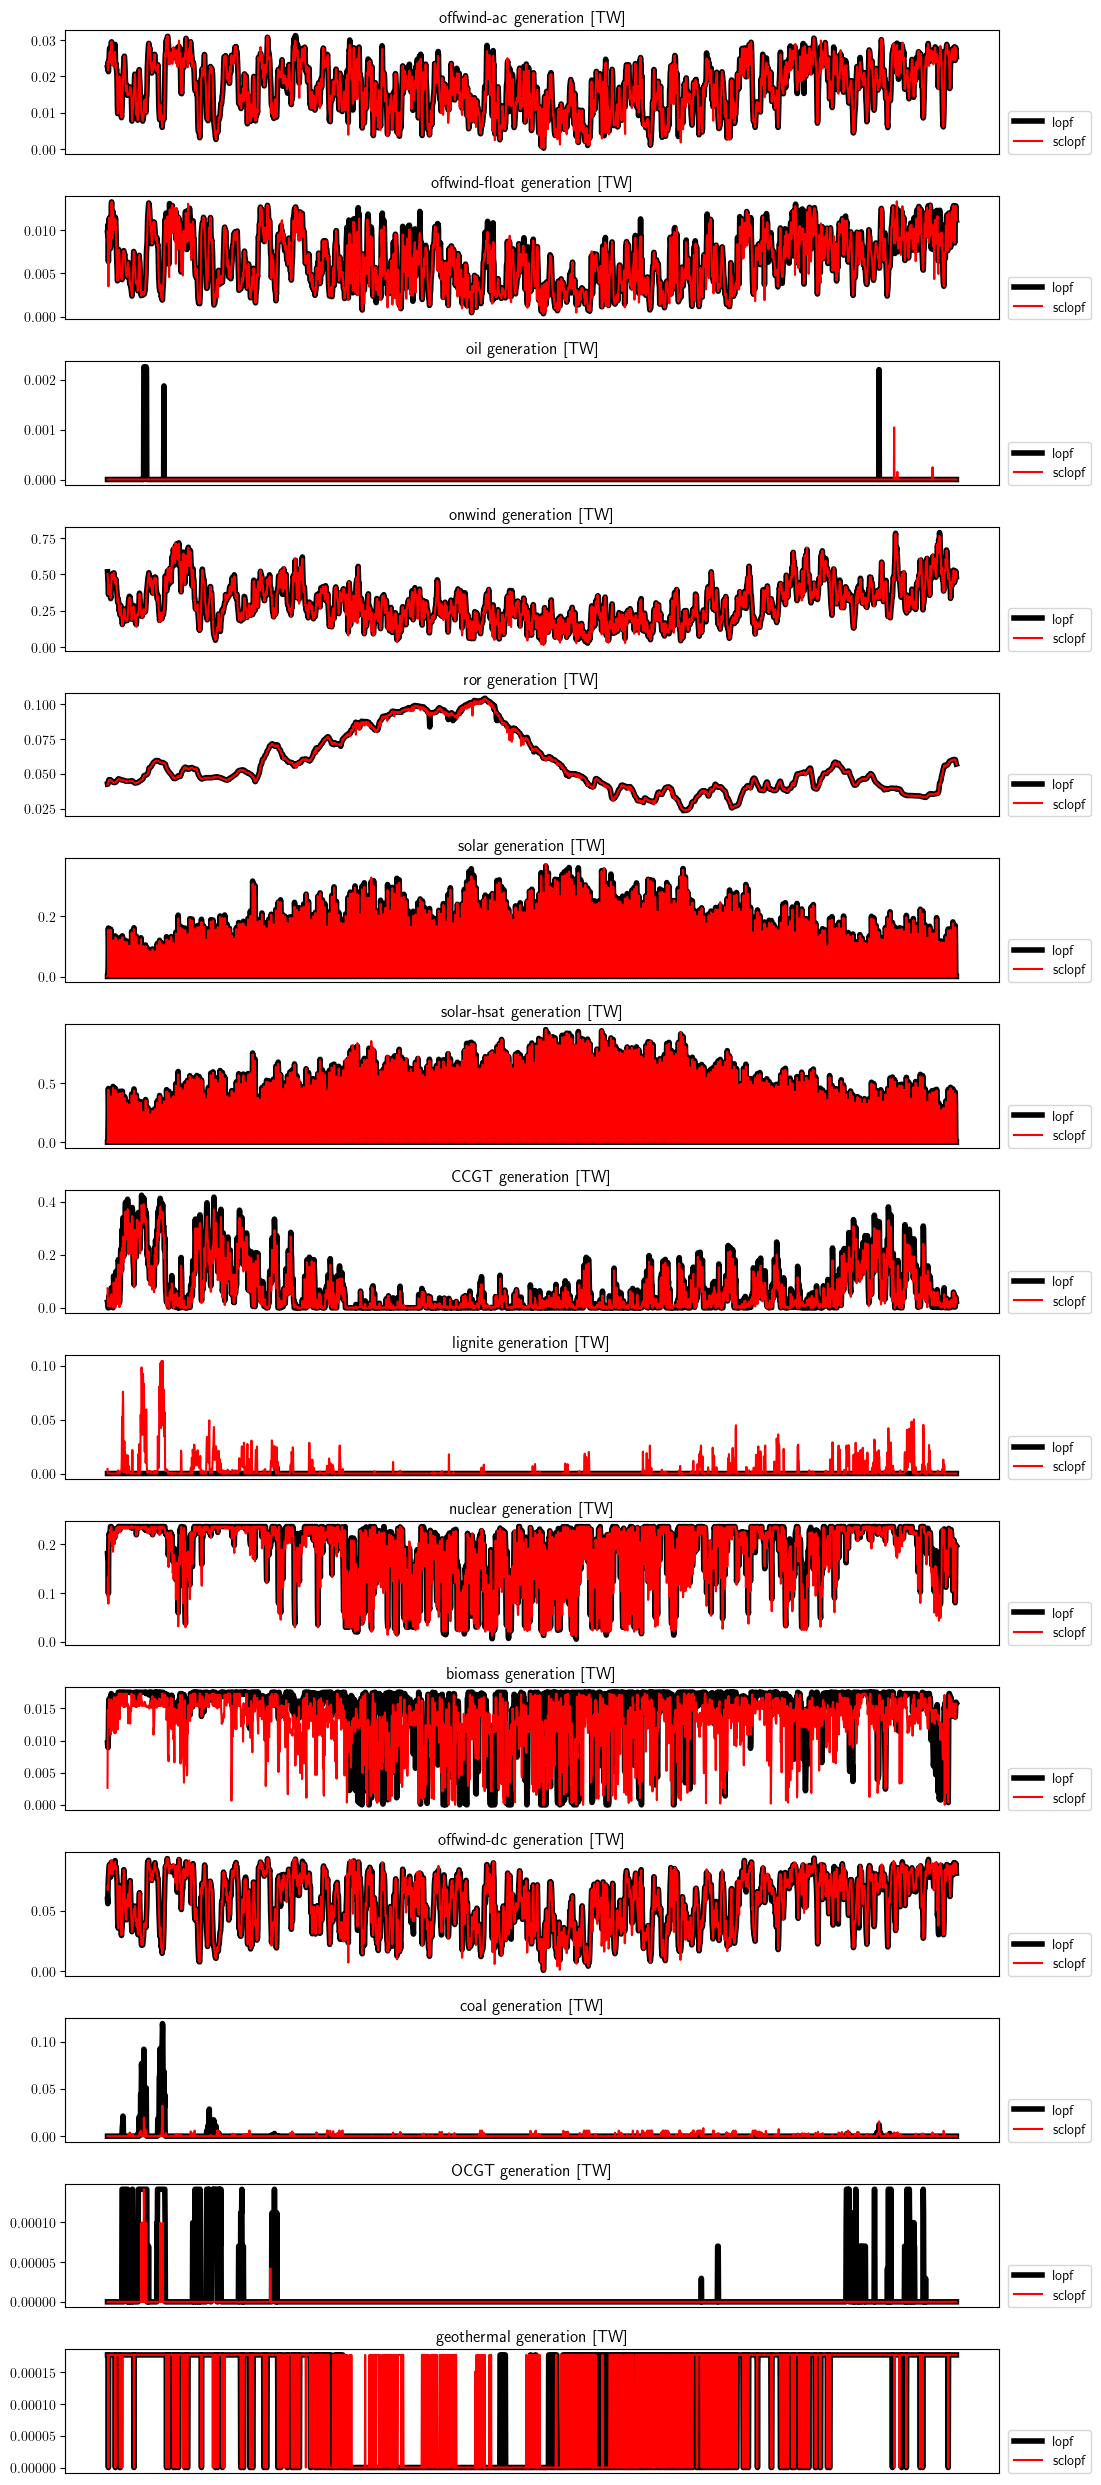

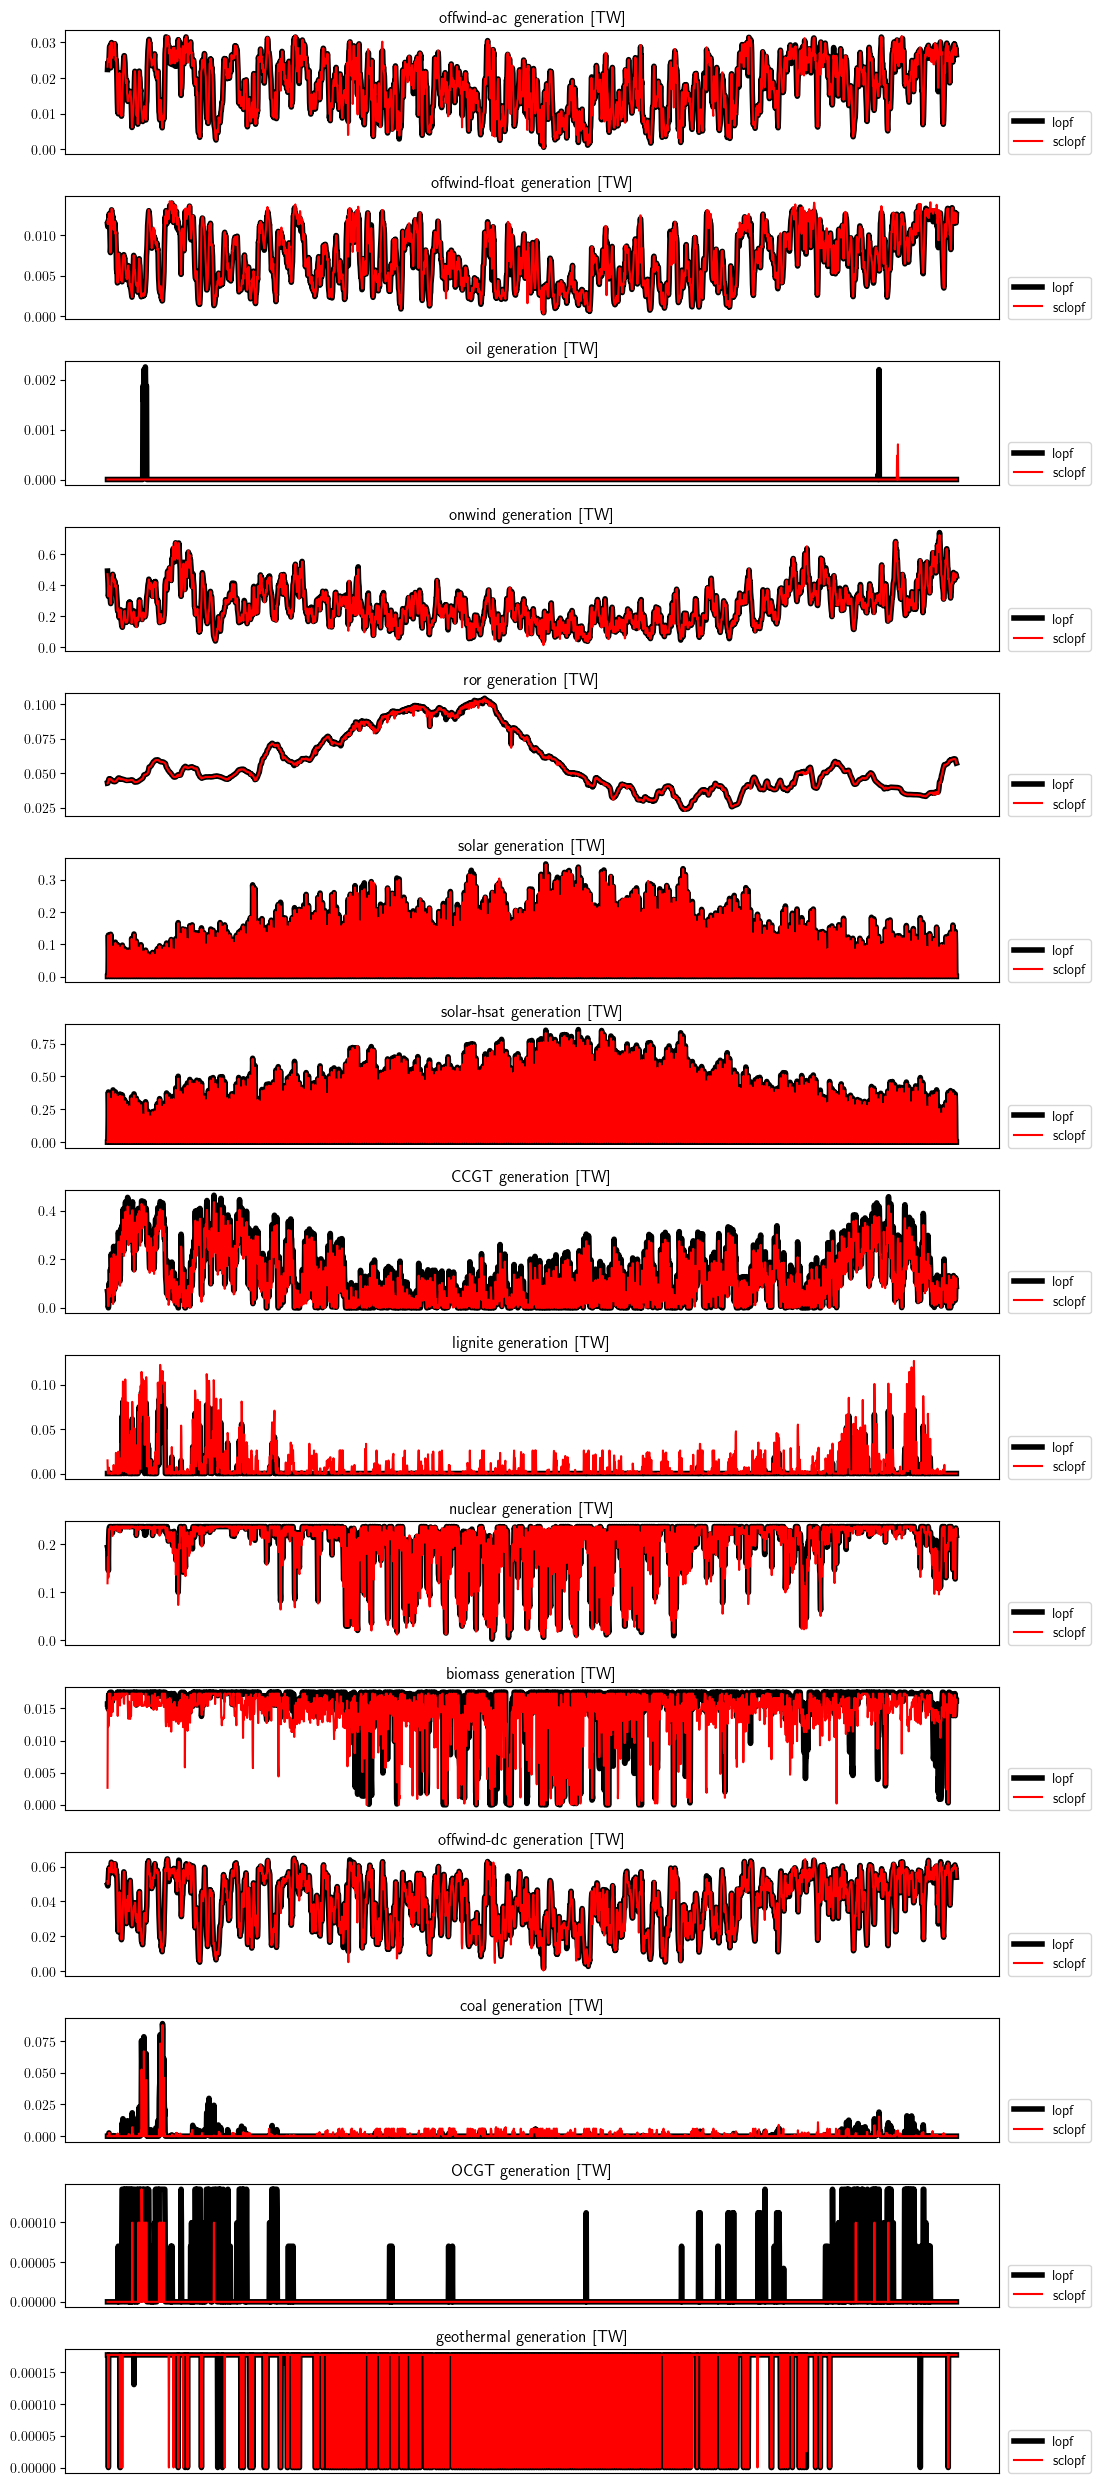

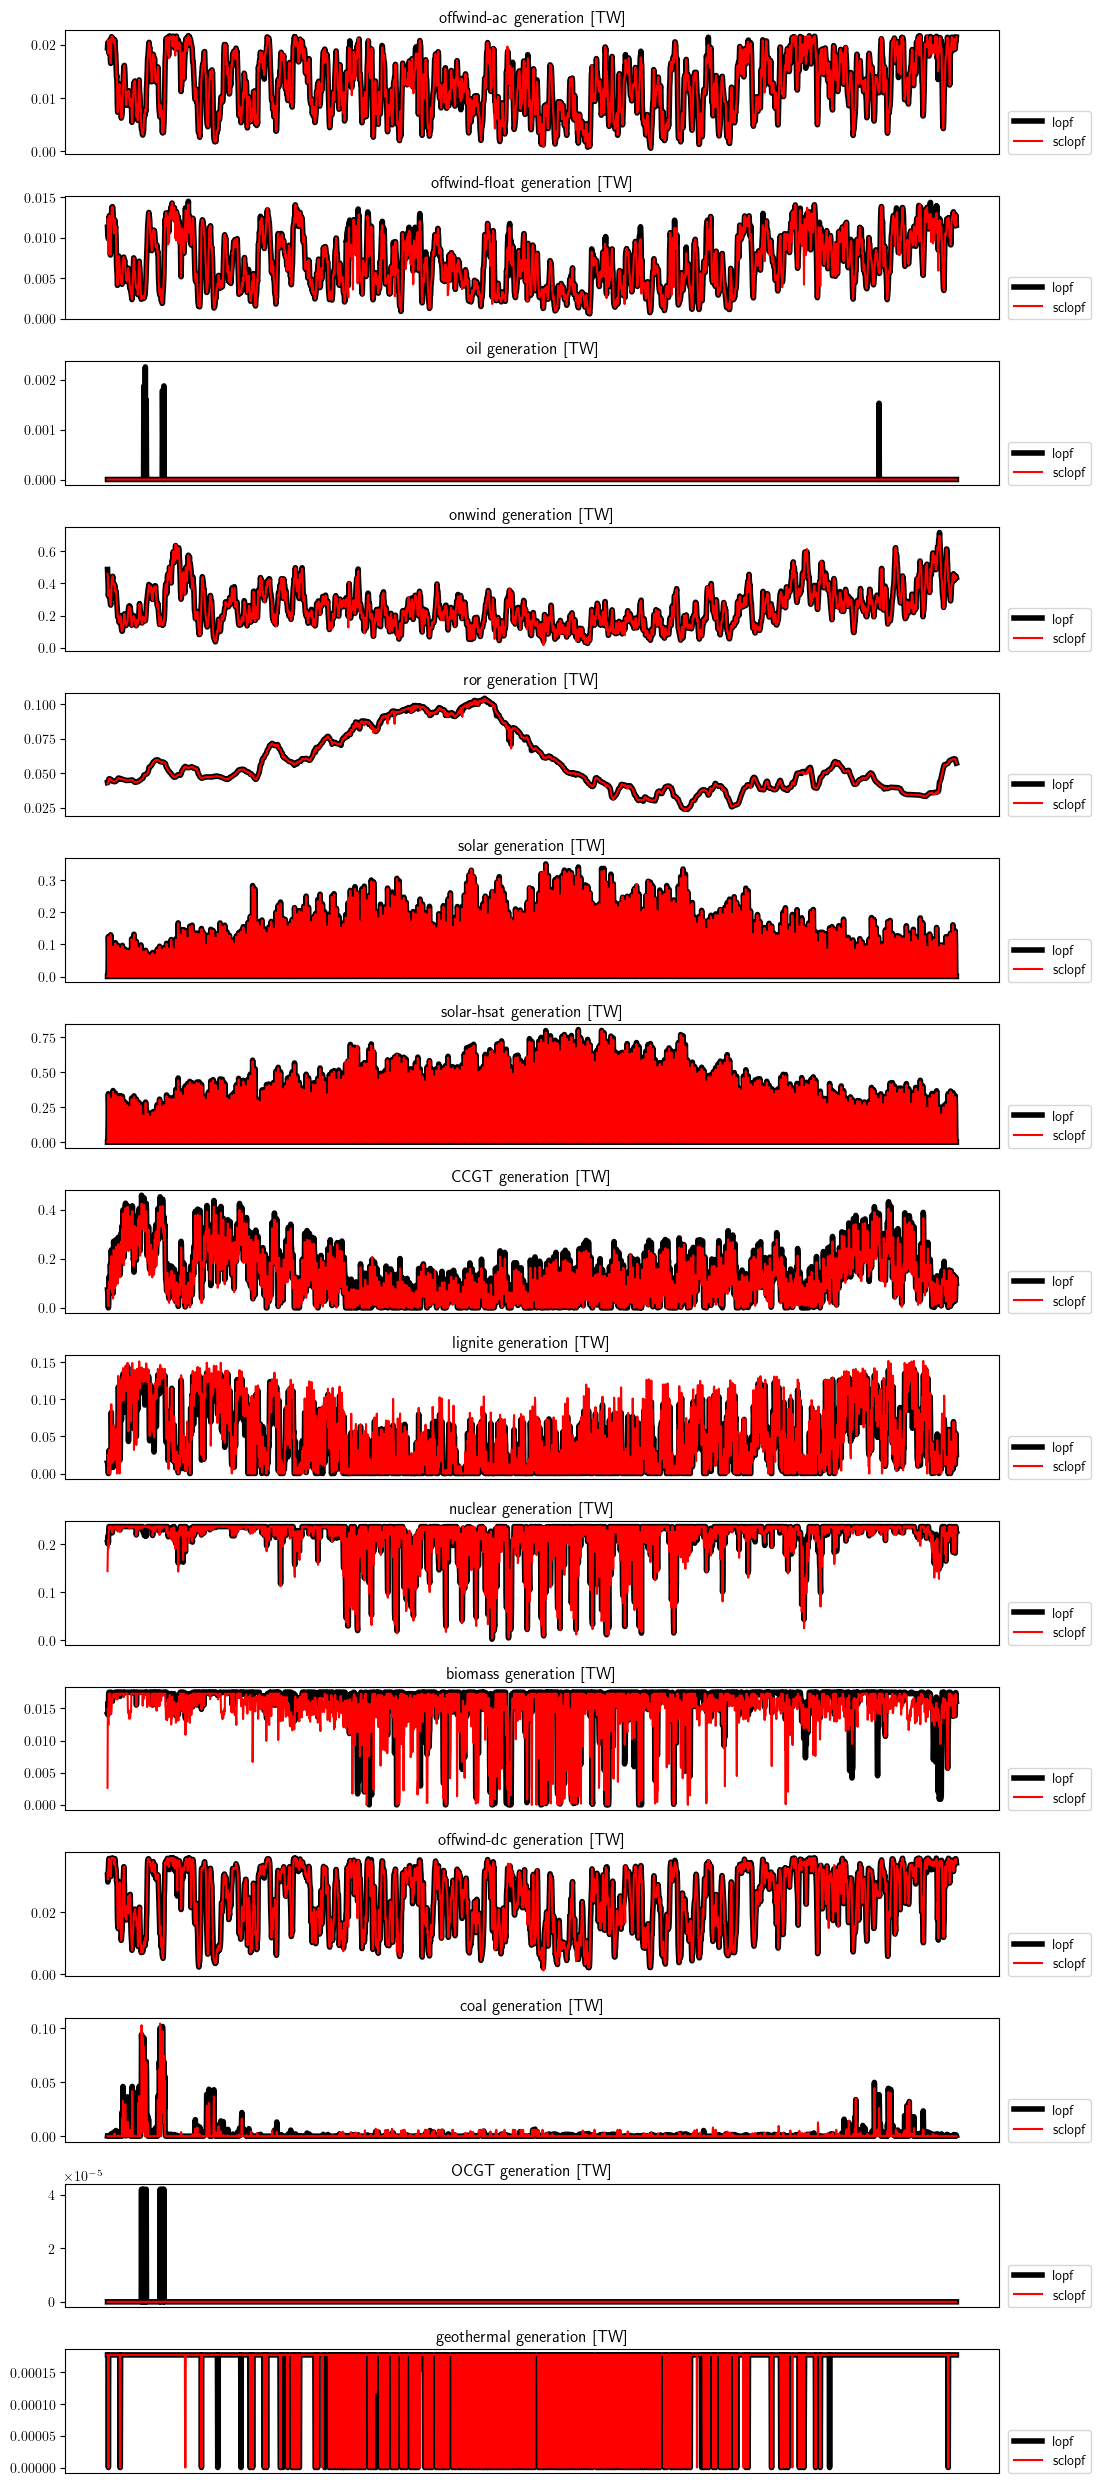

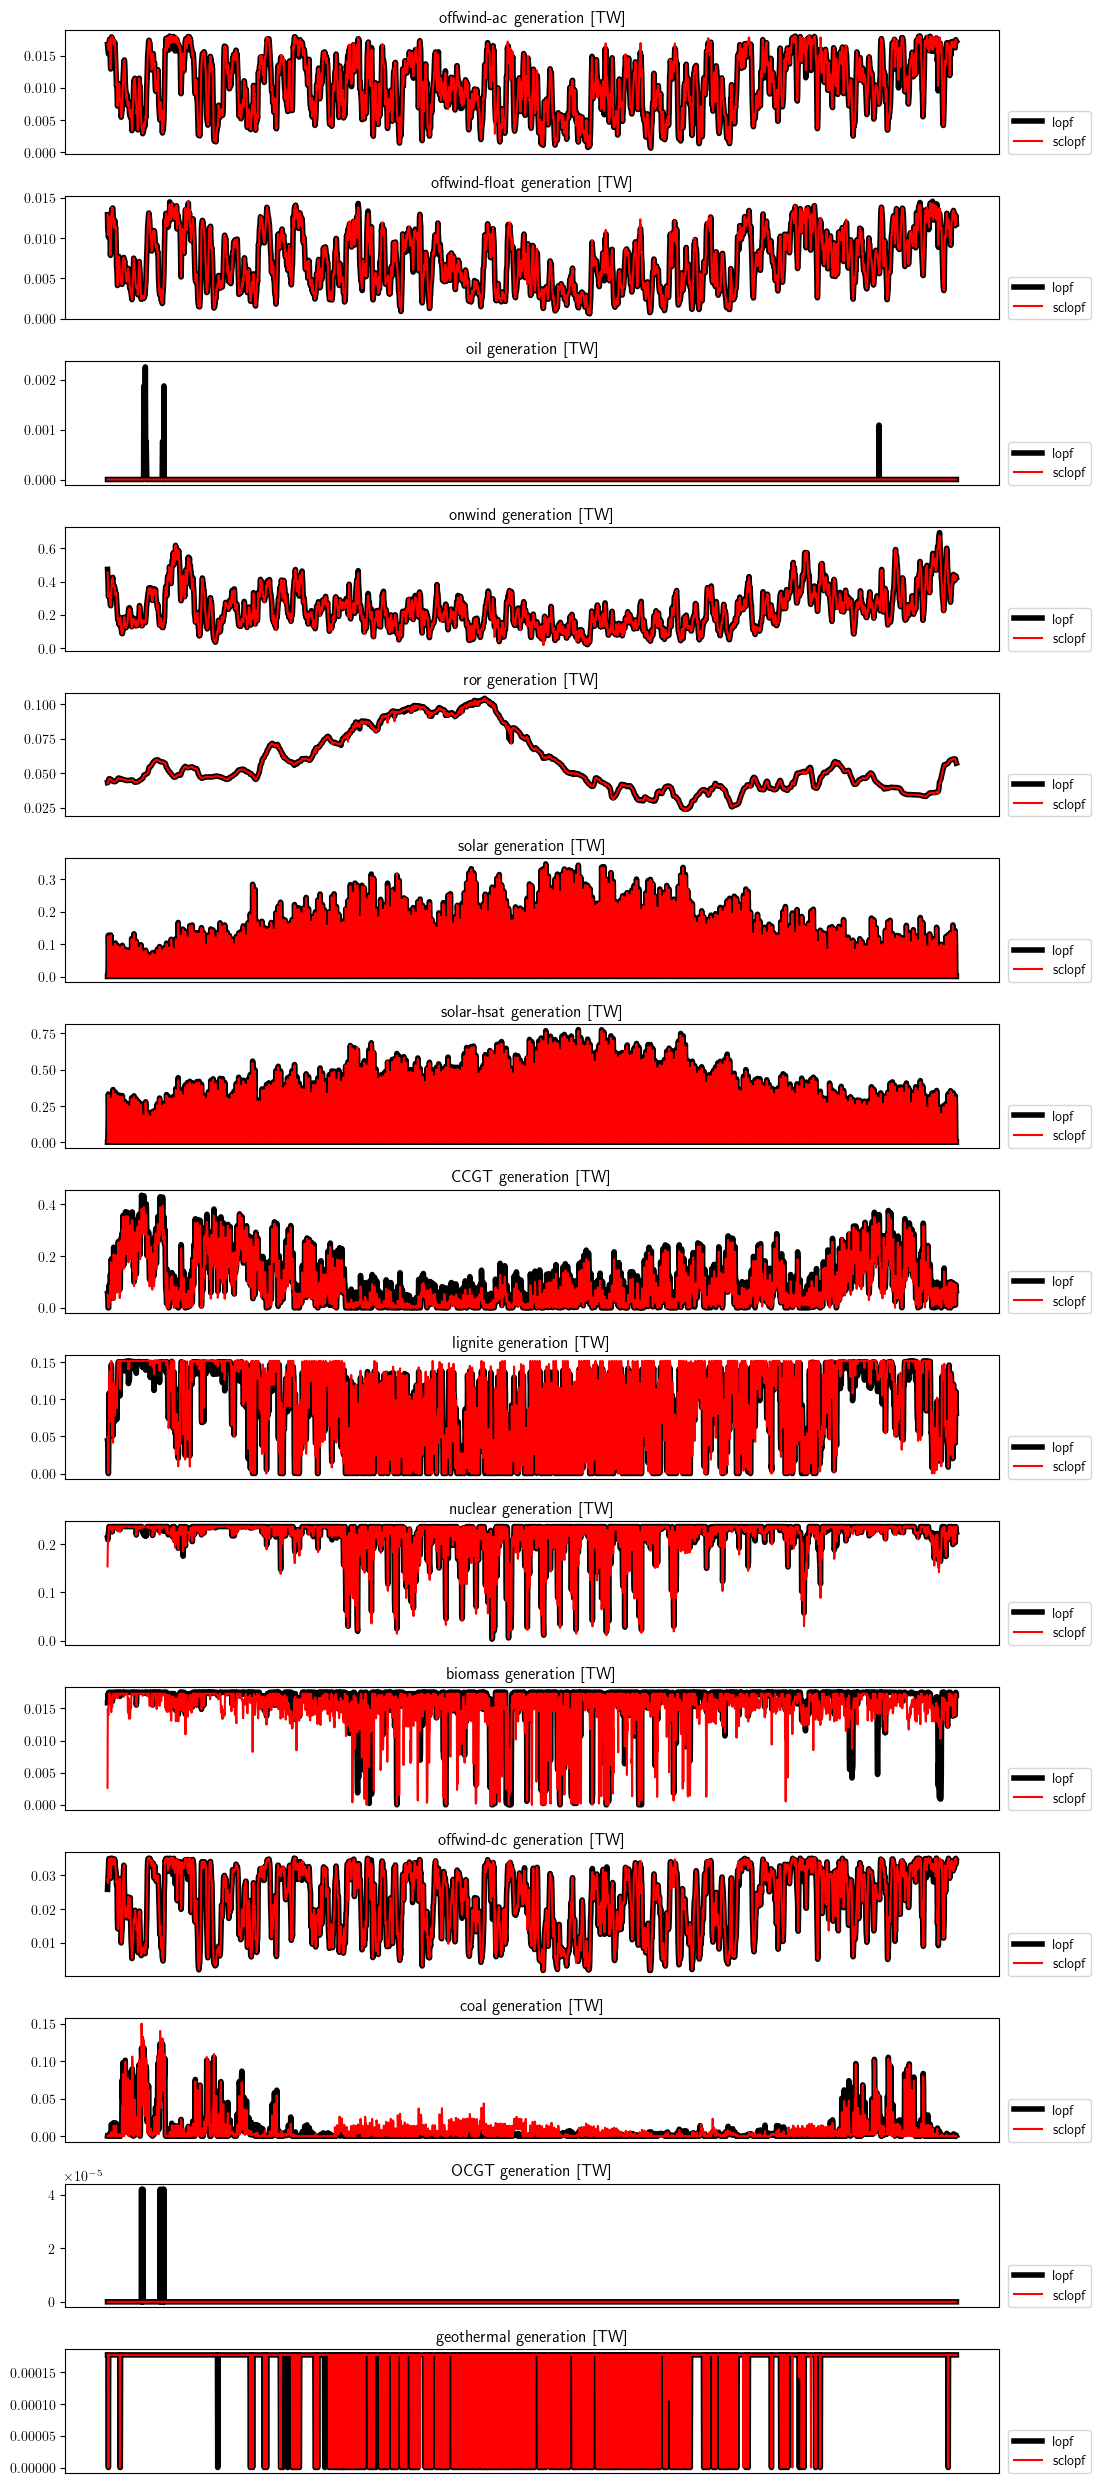

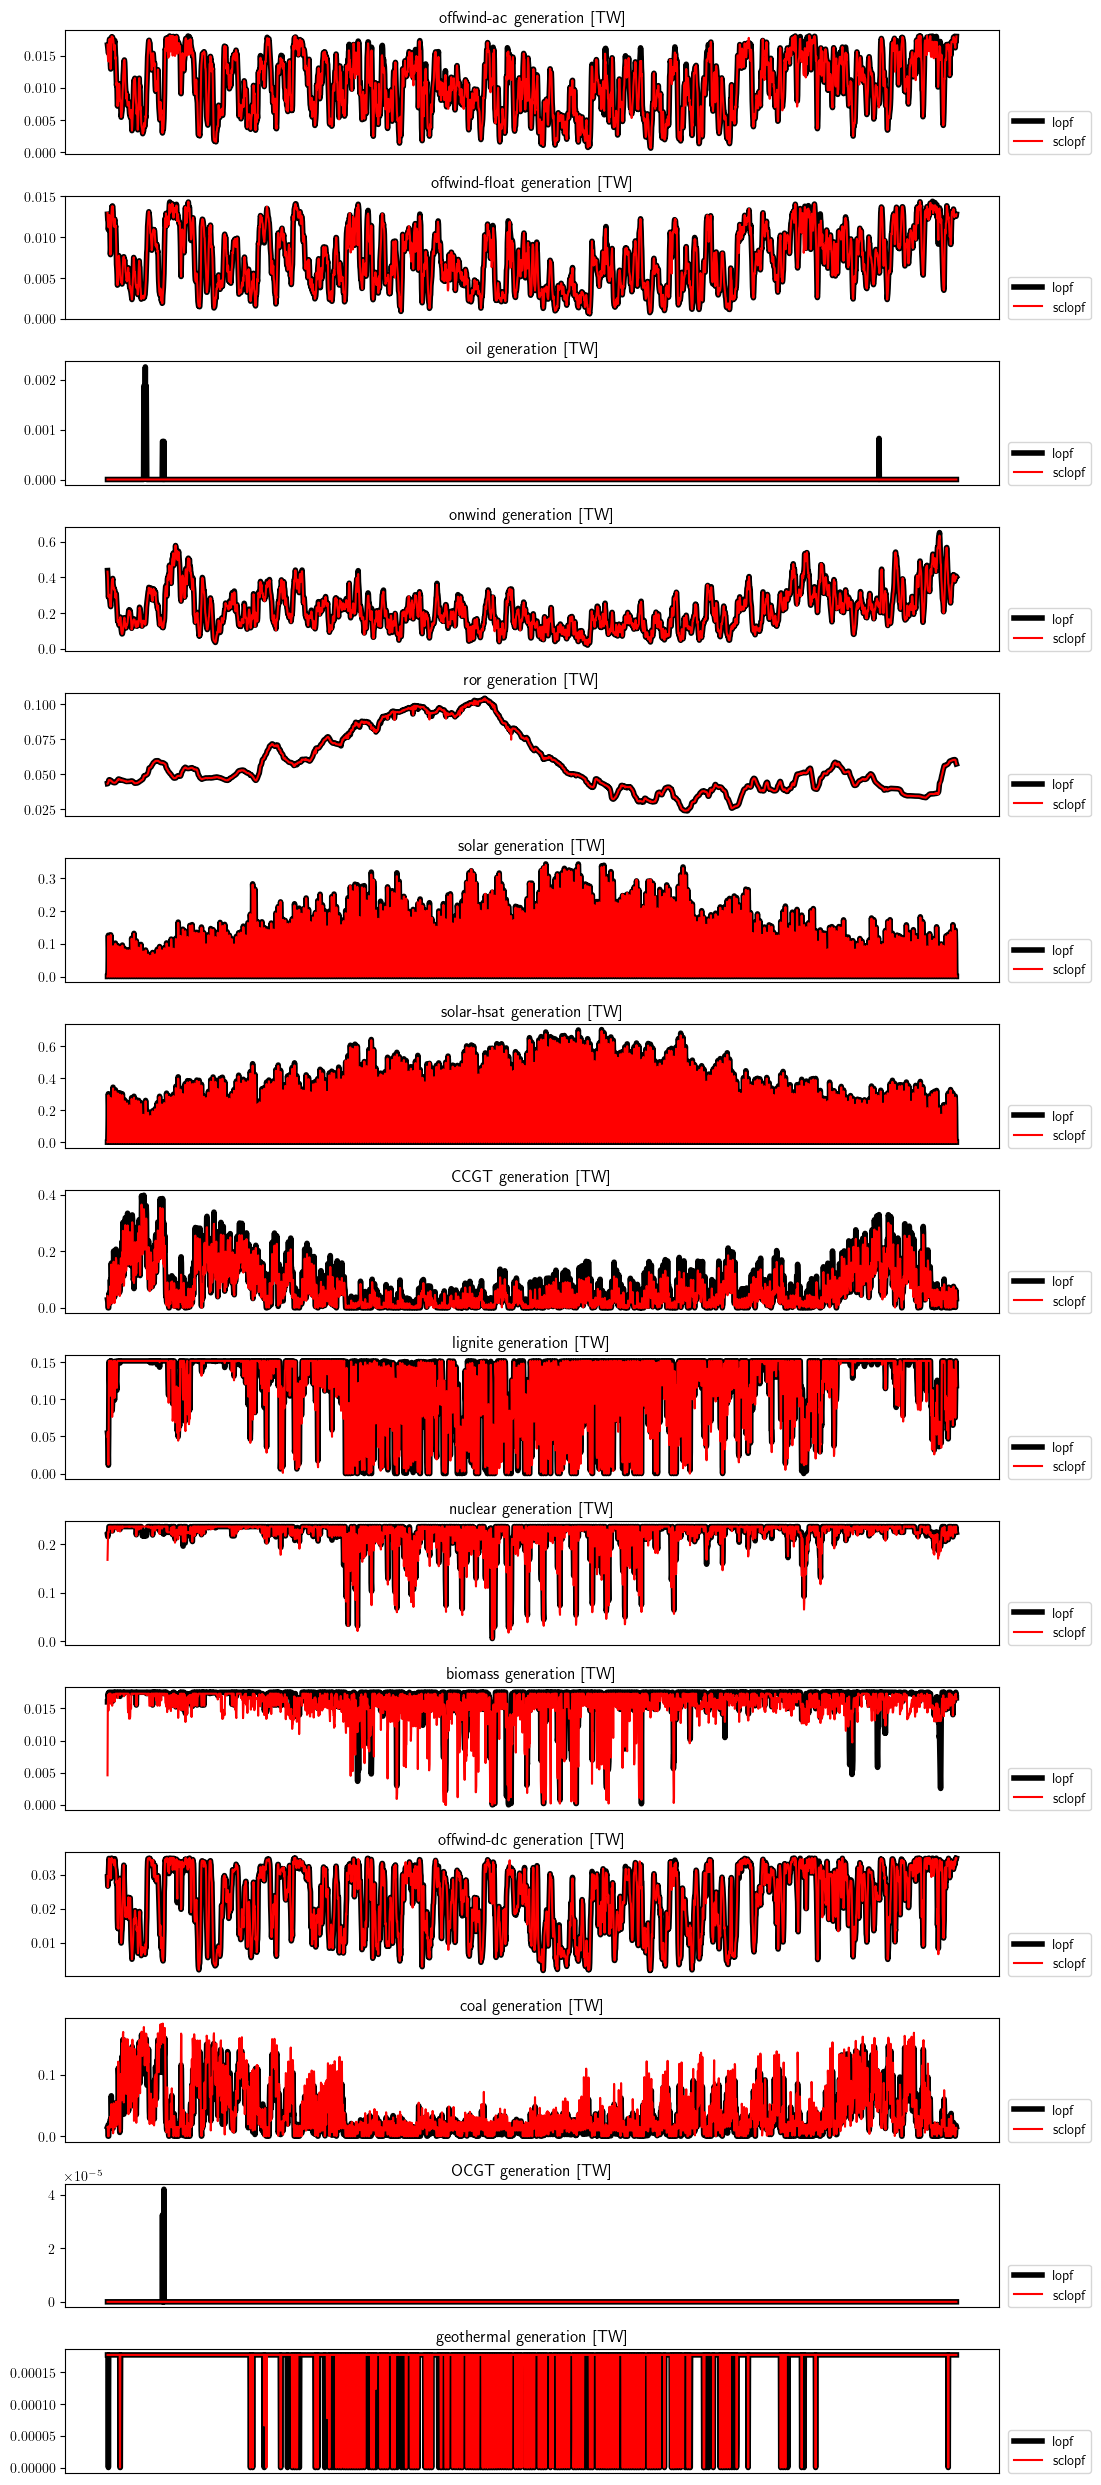

In [ ]:
for level in co2ls:

    n = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc") #lopf
    i = pypsa.Network(f"../workflow/postnetworks/sclopf-elec_s_{n_nodes}_ec_lv1.0_Co2L{level}.nc") #sclopf network



    fig, axes = plt.subplots(len(i.generators.carrier.unique()), 1, figsize=(10, 25))
    fig.tight_layout()

    c = 0
    techsu = i.generators.carrier.unique()
    for ax in axes:
        tech = techsu[c]
        disp_i = (
            i.generators_t.p
            .multiply(i.snapshot_weightings.objective,axis=0).T
            .multiply(i.generators.sign,axis=0)
            .groupby(i.generators.carrier).sum()
            .T[tech].loc[snapshots]/1e6
        )
        if tech == "load":
            disp_n = 0*disp_i
            ax.set_title("redispatch [TW]")
        else:
            disp_n = n.generators_t.p.multiply(n.snapshot_weightings.objective,axis=0).T.groupby(n.generators.carrier).sum().T[tech].loc[snapshots]/1e6
            ax.set_title(tech + " generation [TW]")
            ax.set_xticks([], [])

        ax.plot(disp_n, color="black", linewidth=4, label="lopf")
        ax.plot(disp_i, color="red", zorder=3, label="sclopf")
        ax.legend(loc=[1.01, 0])
        c = c+1
        
        plt.savefig(imagepath + "/"+  str(level) +'/' + "Generation" + '.pdf', bbox_inches='tight')